In [ ]:
import pandas as pd
import numpy as np
import polars as pl
import torch as th
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
from torch.utils.data import DataLoader, random_split
import torch
from pathlib import Path
from google.colab import drive
drive.mount('/content/drive')
import os
from sklearn.metrics import mean_squared_error, mean_absolute_error
import wandb
import matplotlib.pyplot as plt

Mounted at /content/drive


In [ ]:
pip install odfpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 717.0/717.0 kB 19.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for odfpy: filename=odfpy-1.4.1-py2.py3-none-any.whl size=160673 sha256=b7be2066aded1c6daf94c7b4b3390ef3009c139f42545119a34b41c44b30bbf2
  Stored in directory: /root/.cache/pip/wheels/36/5d/63/8243a7ee78fff0f944d638fd0e66d7278888f5e2285d7346b6
Successfully built odfpy


# Create Dataset

Here two sources are being used:
- ERA5 dataset with daily temperature for each city. (117 capitals in total).
- Land-Ocean Temperature Anomaly - Nasa (TRUE DATA) **bold text**

## Global anomaly temperature - NASA data

In [ ]:
## load nasa land-ocean temp anomaly

df_nasa = pd.read_excel('/content/drive/MyDrive/Copernicus_lab/NASA-TEMP-LAND-OCEAR-1981-2025/1981-2025.ods', engine='odf')

In [ ]:
df_long = df_nasa.melt(id_vars=['Year'], var_name='Month', value_name='Value')

df_long['Date'] = pd.to_datetime(df_long['Year'].astype(str) + df_long['Month'], format='%Y%b')

# 3. Clean up: Sort by date and set it as the index
df_ts = df_long.sort_values('Date').set_index('Date').drop(columns=['Year', 'Month'])

df_ts.reset_index(inplace=True)

## create a new column YEAR-MONTH
df_ts['month_year']=pd.to_datetime(df_ts['Date']).dt.strftime("%Y-%m")

## apply scaler to celsius
df_ts['Value'] = df_ts['Value']/ 100


### ADD DATA
new_data = {'Date':['2026-01-01'],
            'Value':[1.08],
            'month_year':['2026-01']}
new = pd.DataFrame.from_dict(new_data)
new['Date'] = pd.to_datetime(new['Date'],yearfirst=True)


## concat
##  concat
df_ts = pd.concat([df_ts, new], axis=0, ignore_index=True)

df_ts.tail()

,Date,Value,month_year
536,2025-09-01,1.25,2025-09
537,2025-10-01,1.19,2025-10
538,2025-11-01,1.21,2025-11
539,2025-12-01,1.05,2025-12
540,2026-01-01,1.08,2026-01


In [ ]:
import pyarrow.dataset as ds

# Create a dataset object (scans the folder metadata)
dataset = ds.dataset("/content/drive/MyDrive/Copernicus_lab/NASA-TEMP-LAND-OCEAR-1981-2025/era5_yearly_chunks", format="parquet")

# Convert to a Table or a Pandas DataFrame
df = dataset.to_table().to_pandas()

In [ ]:
df.tail()

,valid_time,point,latitude,longitude,number,surface,temp_c,place_id,licence,osm_type,...,place_rank,importance,addresstype,name,display_name,boundingbox,timezones,code,name_query,capital
1959506,2026-01-31,112,24.50,54.50,0,0.0,19.256256,41191185.0,"Data © OpenStreetMap contributors, ODbL 1.0. h...",relation,...,10.0,0.673085,city,أبو ظبي,"أبو ظبي, أبوظبي, أبو ظبي, الإمارات العربية الم...","['24.2810331', '24.6018540', '54.2971553', '54...",['Asia/Dubai'],AE,United Arab Emirates,Abu Dhabi
1959507,2026-01-31,113,51.50,0.00,0,0.0,7.016673,257964246.0,"Data © OpenStreetMap contributors, ODbL 1.0. h...",relation,...,10.0,0.892100,city,Greater London,"Greater London, England, United Kingdom","['51.2867601', '51.6918741', '-0.5103751', '0....",['Europe/London'],GB,United Kingdom,London
1959508,2026-01-31,114,25.00,121.50,0,0.0,13.881256,214397054.0,"Data © OpenStreetMap contributors, ODbL 1.0. h...",relation,...,7.0,0.709806,city,臺北市,"臺北市, 臺灣","['24.9605158', '25.2102357', '121.4571436', '1...",['Asia/Taipei'],TW,Taiwan,Taipei
1959509,2026-01-31,115,22.25,114.25,0,0.0,15.110423,426866667.0,"Data © OpenStreetMap contributors, ODbL 1.0. h...",relation,...,8.0,0.816628,city,香港 Hong Kong,"香港 Hong Kong, 中国","['22.1367246', '22.5683333', '113.8172408', '1...",['Asia/Hong_Kong'],HK,Hong Kong,Hong Kong
1959510,2026-01-31,116,18.50,0.00,0,0.0,22.683340,282706844.0,"Data © OpenStreetMap contributors, ODbL 1.0. h...",relation,...,12.0,0.644395,city,San Juan,"San Juan, Puerto Rico, United States","['18.2965306', '18.4719861', '-66.1250904', '-...",['America/Puerto_Rico'],PR,Puerto Rico,San Juan


In [ ]:
## cols to select
cols = ['valid_time', 'point', 'latitude', 'longitude','temp_c', 'place_id', 'name_query','capital']
dff = df[cols]

In [ ]:
df.columns

Index(['valid_time', 'point', 'latitude', 'longitude', 'number', 'surface',
       'temp_c', 'place_id', 'licence', 'osm_type', 'osm_id', 'lat', 'lon',
       'class', 'type', 'place_rank', 'importance', 'addresstype', 'name',
       'display_name', 'boundingbox', 'timezones', 'code', 'name_query',
       'capital'],
      dtype='object')

In [ ]:
dff[~np.isfinite(dff['place_id'].values)]['name_query'].unique()

array(['India', 'Mexico'], dtype=object)

In [ ]:
dff.shape

(1959511, 8)

In [ ]:
## drop all rows which contains nan values.
## This nan values are likely problems when georeferencing the city names
## this issue was propagated into the xarray ERA5 extraction.
## This basically eliminate India and Mexico from the global analysis

dff = dff.dropna().copy()

dff['month_year']=dff['valid_time'].dt.strftime("%Y-%m")

In [ ]:
dff.head()

,valid_time,point,latitude,longitude,temp_c,place_id,name_query,capital,month_year
0,1981-01-01,0,42.50,1.50,-4.691660,395342932.0,Andorra,Andorra la Vella,1981-01
1,1981-01-01,1,41.25,19.75,4.475006,402962725.0,Albania,Tirana,1981-01
2,1981-01-01,2,40.25,44.50,-3.441661,193599592.0,Armenia,Yerevan,1981-01
3,1981-01-01,3,-8.75,13.25,25.745834,35017998.0,Angola,Luanda,1981-01
4,1981-01-01,4,-34.50,0.00,17.297922,409597036.0,Argentina,Buenos Aires,1981-01


In [ ]:
## group by capital, and aggregate monthly the temp
dff_grp = dff.set_index('valid_time').groupby('point').resample('MS').agg({
    'temp_c': 'mean',
    'latitude': 'first',
    'longitude': 'first',
    'name_query': 'first',
    'capital': 'first'
})
print(dff_grp.head())

                    temp_c  latitude  longitude name_query           capital
point valid_time                                                            
0     1981-01-01 -3.410410      42.5        1.5    Andorra  Andorra la Vella
      1981-02-01 -4.417851      42.5        1.5    Andorra  Andorra la Vella
      1981-03-01  1.841606      42.5        1.5    Andorra  Andorra la Vella
      1981-04-01  2.187159      42.5        1.5    Andorra  Andorra la Vella
      1981-05-01  5.110087      42.5        1.5    Andorra  Andorra la Vella


In [ ]:
dff_grp= dff_grp.reset_index().set_index('valid_time')

## Structure the tensor

In [ ]:

import datetime

In [ ]:
### Create arrays and save as npz

## root_dir =
root_dir = os.getcwd()
n_capitals = 117  # number of capitals
n_timepoints = 31  # days


## preprocessing SORT
## turn in lower all capitals to sort it properly
dff['capital'] = dff['capital'].apply(lambda x:x.lower())
dff = dff.sort_values(by=['valid_time','capital']).copy()

uniq_capital = dff['capital'].unique()
month_years = dff['month_year'].unique()
n_samples = len(month_years)

# Pre-allocate arrays
temp_matrices = np.zeros((n_samples, n_capitals, n_timepoints), dtype=np.float32)
masks = np.zeros((n_samples, n_capitals, n_timepoints), dtype=np.float32)
labels = np.zeros(n_samples, dtype=np.float32)
month_year_list = []

for idx, my in enumerate(month_years):
    print(f"processing:{my}")
    # Get data for this month/year
    month_data = dff[dff['month_year'] == my]

    for i, capital in enumerate(uniq_capital):
        capital_data = month_data[month_data['capital'] == capital].sort_values('valid_time')
        temp_values = capital_data['temp_c'].values

        if len(temp_values) > 0:
            temp_matrices[idx, i, :len(temp_values)] = temp_values
            masks[idx, i, :len(temp_values)] = 1.0

    # Get the true anomaly
    anomaly_value = df_ts[df_ts['month_year'] == my]['Value'].values[0]
    labels[idx] = anomaly_value
    month_year_list.append(my)



processing:1981-01
processing:1981-02
processing:1981-03
processing:1981-04
processing:1981-05
processing:1981-06
processing:1981-07
processing:1981-08
processing:1981-09
processing:1981-10
processing:1981-11
processing:1981-12
processing:1982-01
processing:1982-02
processing:1982-03
processing:1982-04
processing:1982-05
processing:1982-06
processing:1982-07
processing:1982-08
processing:1982-09
processing:1982-10
processing:1982-11
processing:1982-12
processing:1983-01
processing:1983-02
processing:1983-03
processing:1983-04
processing:1983-05
processing:1983-06
processing:1983-07
processing:1983-08
processing:1983-09
processing:1983-10
processing:1983-11
processing:1983-12
processing:1984-01
processing:1984-02
processing:1984-03
processing:1984-04
processing:1984-05
processing:1984-06
processing:1984-07
processing:1984-08
processing:1984-09
processing:1984-10
processing:1984-11
processing:1984-12
processing:1985-01
processing:1985-02
processing:1985-03
processing:1985-04
processing:1

In [ ]:
temp_matrices[1,5,:]

array([ 3.2770894 ,  5.1729226 ,  6.4958396 ,  3.631256  ,  2.8083394 ,
        6.850006  ,  8.850006  ,  8.193756  ,  6.975006  ,  3.100006  ,
        0.9750061 ,  0.9958394 , -0.8374939 , -1.6708273 , -0.6708272 ,
        0.2875061 ,  1.5687561 ,  0.9750061 ,  0.08958944, -1.7124939 ,
       -3.9208272 , -2.5666606 , -1.9520773 , -1.2854105 , -0.2124939 ,
        0.23542278,  1.9125061 ,  1.5791727 ,  0.        ,  0.        ,
        0.        ], dtype=float32)

In [ ]:
df_ts

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0.],
      dtype=float32)

In [ ]:
uniq_capital

array(['abu dhabi', 'abuja', 'addis ababa', 'algiers', 'amman',
       'amsterdam', 'andorra la vella', 'ankara', 'antananarivo',
       'ashgabat', 'astana', 'athens', 'bangkok', 'beijing', 'beirut',
       'belgrade', 'berlin', 'bern', 'bishkek', 'bogota', 'bordeaux',
       'brasilia', 'bratislava', 'brazzaville', 'brussels', 'bucharest',
       'budapest', 'buenos aires', 'cairo', 'calafate', 'canberra',
       'caracas', 'copenhagen', 'dakar', 'doha', 'dublin',
       'florianopolis', 'gold coast', 'guatemala city', 'hanoi', 'harare',
       'havana', 'helsinki', 'hong kong', 'jakarta', 'jerusalem',
       'kathmandu', 'kiev', 'kingston', 'kinshasa', 'kuala lumpur',
       'lima', 'lisbon', 'ljubljana', 'london', 'luanda',
       'luxembourg city', 'madrid', 'managua', 'manila', 'maputo',
       'milan', 'minsk', 'monaco', 'montevideo', 'moscow', 'munich',
       'nairobi', 'napoli', 'nicosia', 'oslo', 'ottawa', 'panama city',
       'paris', 'podgorica', 'port louis', 'port of sp

In [ ]:
capital_data = dff[(dff['month_year']=='1981-01')&(dff['capital']=='Andorra la Vella')]
temp_values = capital_data['temp_c'].values

temp_values
# temp_matrices = np.zeros((n_samples, n_capitals, n_timepoints), dtype=np.float32)

# temp_matrices[0, 0, :len(temp_values)] = temp_values

array([-4.6916604 , -4.5666604 , -3.9729106 , -1.6187439 , -4.3791604 ,
       -3.337494  , -4.149994  , -7.9208274 , -6.8583274 , -6.7333274 ,
       -8.910411  , -6.9729104 , -9.108327  , -7.2854104 , -0.7020772 ,
        0.1000061 , -2.087494  , -3.649994  , -0.8999939 ,  0.4750061 ,
       -0.3999939 ,  1.4750061 , -1.2333273 , -4.6916604 , -1.9624939 ,
       -1.5979105 , -0.7124939 , -0.47291055, -2.1708272 , -4.087494  ,
       -2.5979106 ], dtype=float32)

## save it

In [ ]:
import os

In [ ]:
# Save to npz file
path_output = 'content/NASA-TEMP-LAND-OCEAR-1981-2025'
os.makedirs(path_output, exist_ok = True)
np.savez_compressed(
    os.path.join(path_output, 'era5-1981-2025-temp-clean.npz'),
    temp_matrices=temp_matrices,  # shape: (n_samples, n_capitals, n_timepoints)
    masks=masks,                  # shape: (n_samples, n_capitals, n_timepoints)
    labels=labels,                # shape: (n_samples,)
    month_years=np.array(month_year_list, dtype='U'),  # shape: (n_samples,)
    capitals=np.array(uniq_capital, dtype='U')         # shape: (n_capitals,)
)

In [ ]:
uniq_capital

array(['abu dhabi', 'abuja', 'addis ababa', 'algiers', 'amman',
       'amsterdam', 'andorra la vella', 'ankara', 'antananarivo',
       'ashgabat', 'astana', 'athens', 'bangkok', 'beijing', 'beirut',
       'belgrade', 'berlin', 'bern', 'bishkek', 'bogota', 'bordeaux',
       'brasilia', 'bratislava', 'brazzaville', 'brussels', 'bucharest',
       'budapest', 'buenos aires', 'cairo', 'calafate', 'canberra',
       'caracas', 'copenhagen', 'dakar', 'doha', 'dublin',
       'florianopolis', 'gold coast', 'guatemala city', 'hanoi', 'harare',
       'havana', 'helsinki', 'hong kong', 'jakarta', 'jerusalem',
       'kathmandu', 'kiev', 'kingston', 'kinshasa', 'kuala lumpur',
       'lima', 'lisbon', 'ljubljana', 'london', 'luanda',
       'luxembourg city', 'madrid', 'managua', 'manila', 'maputo',
       'milan', 'minsk', 'monaco', 'montevideo', 'moscow', 'munich',
       'nairobi', 'napoli', 'nicosia', 'oslo', 'ottawa', 'panama city',
       'paris', 'podgorica', 'port louis', 'port of sp


# Model

## Dataset Class
this function is made to work with the tensor produced above

In [ ]:

class TempDSMask(Dataset):
    def __init__(self, npz_path, return_mask=True, exclude_2025=True):
        """
        Load precomputed temperature data from npz file.

        Args:
            npz_path: Path to the .npz file
            return_mask: Whether to return mask along with data
            exclude_2025: Wether exclude 2025 or not
        """
        self.exclude_2025 = exclude_2025
        self.return_mask = return_mask

        # Load all data at once
        data = np.load(npz_path,
                        allow_pickle=True,
                      ## encoding="latin1"
                       )

        # Determine split point (last 12 months for 2025)
        split_idx = -12 if exclude_2025 else None

        ## exclude 2025 to use for testing only
        self.temp_matrices_n = data['temp_matrices'][:split_idx]   # (n_samples, n_capitals, n_timepoints) ## non normalized
        self.masks = data['masks'][:split_idx]   # (n_samples, n_capitals, n_timepoints)
        self.labels = data['labels'][:split_idx] # (n_samples,)
        self.month_years = data['month_years'][:split_idx] # (n_samples,)
        self.capitals = data['capitals'].astype(str)  # (n_capitals,)

        # Store 2025 data separately (always available)
        self.temp_matrices_2025_n = data['temp_matrices'][-12:]
        self.masks_2025 = data['masks'][-12:]
        self.labels_2025 = data['labels'][-12:]
        self.month_years_2025 = data['month_years'][-12:]


        # Normalize using ONLY the training data statistics (important!)
        self.mu, self.std = self._compute_stats(self.temp_matrices_n)
        self.temp_matrices = self._normalize(self.temp_matrices_n, self.mu, self.std)

        # Normalize 2025 data using TRAINING statistics (prevent data leakage)
        self.temp_matrices_2025 = self._normalize(self.temp_matrices_2025_n, self.mu, self.std)

        ## exclude the last year - 2025 for testing
        print(f"Dataset loaded from {npz_path}:")
        print(f"  - Samples: {len(self.labels)}")
        print(f"  - Capitals: {len(self.capitals)}")
        print(f"  - Timepoints: {self.temp_matrices.shape[2]}")
        print(f"  - Shape: {self.temp_matrices.shape}")

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = self.temp_matrices[idx]  # shape: (n_capitals, n_timepoints)
        y = self.labels[idx]          # scalar

        if self.return_mask:
            mask = self.masks[idx]    # shape: (n_capitals, n_timepoints)
            return x, np.array(y).reshape(-1), mask

        return x, (np.array(y)).reshape(-1)

    def get_month_year(self, idx):
        """Helper to get month_year for a given index"""
        return self.month_years[idx]

        ## normalize
    def _compute_stats(self, temp_matrices):
        """Compute mean and std from temperature matrices"""
        tt = torch.tensor(temp_matrices, dtype=torch.float32)
        mu = tt.mean(dim=0)
        std = tt.std(dim=0)
        return mu, std

    def return_mu_std(self):
      """
      Return two tensors: mean and std
      """
      return self.mu, self.std

    def _normalize(self, temp_matrices, mu, std):
        """Normalize using provided mean and std"""
        tt = torch.tensor(temp_matrices, dtype=torch.float32)
        tts = (tt - mu) / (std + 1e-8)  # Add epsilon to avoid division by zero
        return tts.numpy()

    def get_2025_dataset(self):
        """Return a separate Dataset object for 2025 holdout data"""
        return TempDS2025(
            temp_matrices=self.temp_matrices_2025,
            masks=self.masks_2025,
            labels=self.labels_2025,
            month_years=self.month_years_2025,
            return_mask=self.return_mask
        )


class TempDS2025(Dataset):
    """Separate dataset class for 2025 holdout data"""
    def __init__(self, temp_matrices, masks, labels, month_years, return_mask=True):
        self.temp_matrices = temp_matrices
        self.masks = masks
        self.labels = labels
        self.month_years = month_years
        self.return_mask = return_mask

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = self.temp_matrices[idx]
        y = self.labels[idx]

        if self.return_mask:
            mask = self.masks[idx]
            return (torch.FloatTensor(x),
                   torch.tensor([y], dtype=torch.float32),
                    torch.FloatTensor(mask)
                    )

        return torch.FloatTensor(x), torch.tensor([y], dtype=torch.float32)

    def get_month_year(self, idx):
        return self.month_years[idx]

### Dataset Fine Tunning

In [ ]:

class TempDSMask_Finetun(Dataset):
    def __init__(self, npz_path, return_mask=True,  mu=None, std=None):
        """
        Load precomputed temperature data from npz file.

        Args:
            npz_path: Path to the .npz file
            return_mask: Whether to return mask along with data
            exclude_2025: Wether exclude 2025 or not
            mu:tensor  - mean - Same mean and std used for training
            std:tensor - std - Same mean and std used for training
            std: std
        """
        self.return_mask = return_mask
        self.mu = mu
        self.std = std
        if mu is None or std is None:
            raise ValueError("mu and std must be provided for normalization")

        # Load all data at once
        data = np.load(npz_path,
                        allow_pickle=True,
                       )



        self.temp_matrices_n = data['temp_matrices']  # (n_samples, n_capitals, n_timepoints) ## non normalized
        self.masks = data['masks'] # (n_samples, n_capitals, n_timepoints)
        self.labels = data['labels'] # (n_samples,)
        self.month_years = data['month_years'] # (n_samples,)
        self.capitals = data['capitals'].astype(str)  # (n_capitals,)


        # Normalize using ONLY the training data statistics (important!)
        self.temp_matrices = self._normalize(self.temp_matrices_n, self.mu, self.std)


        ## exclude the last year - 2025 for testing
        print(f"Dataset loaded from {npz_path}:")
        print(f"  - Samples: {len(self.labels)}")
        print(f"  - Capitals: {len(self.capitals)}")
        print(f"  - Timepoints: {self.temp_matrices.shape[2]}")
        print(f"  - Shape: {self.temp_matrices.shape}")

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = self.temp_matrices[idx]  # shape: (n_capitals, n_timepoints)
        y = self.labels[idx]          # scalar

        if self.return_mask:
            mask = self.masks[idx]    # shape: (n_capitals, n_timepoints)
            return x, np.array(y).reshape(-1), mask

        return x, (np.array(y)).reshape(-1)

    def get_month_year(self, idx):
        """Helper to get month_year for a given index"""
        return self.month_years[idx]

    def _normalize(self, temp_matrices, mu, std):
        """Normalize using provided mean and std"""
        tt = torch.tensor(temp_matrices, dtype=torch.float32)
        tts = (tt - mu) / (std + 1e-8)  # Add epsilon to avoid division by zero
        return tts.numpy()






In [ ]:
path_file = 'drive/MyDrive/Copernicus_lab/NASA-TEMP-LAND-OCEAR-1981-2025/era5-1981-2025-temp-clean.npz'

# Load dataset
dataset = TempDSMask(path_file, return_mask=True)

# Split into train/val/test
train_size = int(0.75 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

# Test it
x, y, mask = dataset[0]
print(f"\nSample shapes:")
print(f"  X: {x.shape}")      # (117, 31)
print(f"  Y: {y.shape}")      # ()
print(f"  Mask: {mask.shape}") # (117, 31)

# Test batch
x_batch, y_batch, mask_batch = next(iter(train_loader))
print(f"\nBatch shapes:")
print(f"  X: {x_batch.shape}")      # (32, 117, 31)
print(f"  Y: {y_batch.shape}")      # (32,)

Dataset loaded from drive/MyDrive/Copernicus_lab/NASA-TEMP-LAND-OCEAR-1981-2025/era5-1981-2025-temp-clean.npz:
  - Samples: 528
  - Capitals: 117
  - Timepoints: 31
  - Shape: (528, 117, 31)

Sample shapes:
  X: (117, 31)
  Y: (1,)
  Mask: (117, 31)

Batch shapes:
  X: torch.Size([32, 117, 31])
  Y: torch.Size([32, 1])


In [ ]:
# Load dataset (excludes 2025 by default)
dataset = TempDS(
    '/content/drive/MyDrive/Copernicus_lab/NASA-TEMP-LAND-OCEAR-1981-2025/temp_data.npz',
    return_mask=True,
    exclude_2025=True  # Default
)

# Split into train/val (2025 is already excluded)
train_size = int(0.75 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Get 2025 holdout dataset
dataset_2025 = dataset.get_2025_dataset()
test_2025_loader = DataLoader(dataset_2025, batch_size=32, shuffle=False)

print(f"Train size: {len(train_dataset)}")
print(f"Val size: {len(val_dataset)}")
print(f"2025 holdout size: {len(dataset_2025)}")

In [ ]:
x.shape

(117, 31)

### model class

In [ ]:

## X shape = 117,31
class TempCNN(nn.Module):
    def __init__(self, in_channels, n_classes, dropout):
        super().__init__()
        self.in_channels = in_channels
        self.n_classes = 1
        self.dropout = dropout


        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels, 256, kernel_size=5, padding='same'),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Dropout(p=self.dropout)
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(256, 512, kernel_size=5, padding='same'),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Dropout(p=self.dropout)
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(512, 256, kernel_size=3, padding='same'),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Dropout(p=self.dropout)
        )

        self.conv4 = nn.Sequential(
            nn.Conv1d(256, 128, kernel_size=3, padding='same'),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Dropout(p=self.dropout)
        )
        self.fc1 = nn.Sequential(
            nn.Linear(128,64),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Dropout(p=self.dropout)
        )
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        # x shape: (batch, channels, length)
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x= self.conv4(x)

        # gap
        x = torch.mean(x, dim=2)

        x = self.fc1(x)
        x = self.fc2(x)

        return x



In [ ]:
class MaskTempCNN(nn.Module):
    def __init__(self, in_channels, n_classes, dropout):
        super().__init__()
        self.in_channels = in_channels
        self.n_classes = 1
        self.dropout = dropout


        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels, 256, kernel_size=5, padding='same'),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Dropout(p=self.dropout)
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(256, 512, kernel_size=5, padding='same'),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Dropout(p=self.dropout)
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(512, 256, kernel_size=3, padding='same'),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Dropout(p=self.dropout)
        )

        self.conv4 = nn.Sequential(
            nn.Conv1d(256, 128, kernel_size=3, padding='same'),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Dropout(p=self.dropout)
        )
        self.fc1 = nn.Sequential(
            nn.Linear(128, 64),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Dropout(p=self.dropout)
        )
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x, mask=None):
        # x shape: (batch, channels, length) = (batch, 117, 31)

        # Apply mask before processing (zero out masked positions)
        if mask is not None:
            # mask shape: (batch, 117, 31)
            # Apply mask by multiplying (0 where data is missing)
            x = x * mask

        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)

        # Global average pooling
        # If using mask, do masked average pooling
        if mask is not None:
            # After convolutions, we need to apply pooling that respects the mask
            # Simple approach: masked mean
            # x shape: (batch, 128, 31)
            # We need to compute mean only over non-masked positions

            # Downsample mask to match conv output if needed
            # For 'same' padding, length should still be 31
            mask_pooled = torch.mean(mask, dim=1, keepdim=True)  # (batch, 1, 31)

            # Masked sum / count of valid positions
            valid_count = mask_pooled.sum(dim=2, keepdim=True).clamp(min=1)  # Avoid div by 0
            x = (x * mask_pooled).sum(dim=2) / valid_count.squeeze(-1)  # (batch, 128)
        else:
            # Standard global average pooling
            x = torch.mean(x, dim=2)  # (batch, 128)

        x = self.fc1(x)
        x = self.fc2(x)

        return x

### epoch

In [ ]:
from pyarrow import output_stream
def train_epoch(model, loader, criterion, optimizer, device: str ='cuda',use_mask=True):

    losses = []
    mse_scores = []

    # TODO: call the function to set the training mode
    model.train()

    for batch in loader:
      if use_mask and len(batch) == 3:
          x, y, mask = batch
          x, y, mask = x.to(device), y.to(device), mask.to(device)
      else:
          x, y = batch[:2]  # In case batch has mask but we don't use it
          x, y = x.to(device), y.to(device)
          mask = None

        ## zero gradients
      optimizer.zero_grad()

        ## forward
        # Forward pass (pass mask if model supports it)
      if use_mask and mask is not None:
          outputs = model(x, mask=mask)
      else:
          outputs = model(x)

        ## loss
      loss = criterion(outputs.squeeze(), y.squeeze())

        ##
      loss.backward()

        ## update optimizer
      optimizer.step()

      with torch.no_grad():
        losses.append(loss.detach().item())

        y_true = y.cpu().numpy().flatten()
        y_pred = outputs.detach().cpu().numpy().flatten()

        mse = mean_squared_error(y_true, y_pred)
        mse_scores.append(mse)

    return losses, mse_scores

def evaluate_model(model, loader, criterion, device: str ='cuda',use_mask=True):

    total_loss = 0

    yTrue = []
    yPred = []

    # TODO: call the function to set the eval model
    model.eval()

    with torch.no_grad():
        for batch in loader:
          if use_mask and len(batch) == 3:
                x, y, mask = batch
                x, y, mask = x.to(device), y.to(device), mask.to(device)
          else:
                x, y = batch[:2]
                x, y = x.to(device), y.to(device)
                mask = None

          ## output
          # Forward pass
          if use_mask and mask is not None:
             outputs = model(x, mask=mask)
          else:
             outputs = model(x)

          ## loss
          loss= criterion(outputs.squeeze(), y.squeeze())
          total_loss += loss.item()

          yTrue.extend(y.cpu().numpy().flatten())
          yPred.extend(outputs.cpu().numpy().flatten())


    # TODO: Average the loss
    avg_loss = total_loss / len(loader)

    #Compute the MSE SCORE
    mse_score = mean_squared_error(yTrue, yPred)
    mae_score = mean_absolute_error(yTrue, yPred)

    # TODO: Return loss, mse_ , predict
    return avg_loss, mse_score, (yTrue, yPred)


def save_model(model, optimizer, epoch, filefolder, val_loss):
    """Save model checkpoint"""
    filename = "model_checkpoint.pth"
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_loss': val_loss,
    }, filefolder / filename)


def train_model(model, train_dataloader, val_dataloader, criterion, optimizer,
                n_epochs, resultfolder, device, use_mask=True, use_wandb=True,
                wandb_project=None, wandb_config=None,wandb_run_name=None, verbose=True):
    """
    Train model with optional wandb logging.

    Args:
        model: PyTorch model
        train_dataloader: Training data loader
        val_dataloader: Validation data loader
        criterion: Loss function
        optimizer: Optimizer
        n_epochs: Number of epochs
        resultfolder: Path to save checkpoints
        device: Device to train on
        use_mask: Whether to use mask in forward pass
        use_wandb: Whether to log to wandb
        wandb_project: Wandb project name
        wandb_config: Dict of config parameters to log
        verbose: Print training progress
    """

    # Initialize wandb
    if use_wandb:
        # Generate unique run name if not provided
        if wandb_run_name is None and wandb_config is not None:
            wandb_run_name = generate_run_name(wandb_config)

        wandb.init(
            project=wandb_project or "temperature-lstm",
            name=wandb_run_name,
            config=wandb_config or {},
            reinit=True
        )

        # Log model architecture
        wandb.watch(model, log='all', log_freq=100)

        if verbose:
            print(f"wandb run: {wandb.run.name}")
            print(f"wandb url: {wandb.run.url}")

    # Prepare DataFrames to store metrics
    columns = ['train_loss', 'train_mse', 'val_loss', 'val_mse']
    results_epoch_df = pd.DataFrame(columns=columns)
    results_train_df = pd.DataFrame(columns=columns[:2])

    # Initial evaluation before training
    train_loss, train_mse, _ = evaluate_model(model, train_dataloader, criterion, device, use_mask)
    val_loss, val_mse, _ = evaluate_model(model, val_dataloader, criterion, device, use_mask)
    results_epoch_df.loc[0] = [train_loss, train_mse, val_loss, val_mse]

    best_val_loss = val_loss
    best_epoch = 0

    if verbose:
        print(f"Epoch 0 (initial): train loss={np.round(train_loss, 6)}, train MSE={np.round(train_mse, 6)}, "
              f"val loss={np.round(val_loss, 6)}, val MSE={np.round(val_mse, 6)}")

    # Log initial metrics to wandb
    if use_wandb:
        wandb.log({
            "epoch": 0,
            "train_loss": train_loss,
            "train_mse": train_mse,
            "val_loss": val_loss,
            "val_mse": val_mse,
        })

    # Training loop
    for epoch in range(1, n_epochs + 1):
        # Train for one epoch
        train_losses, train_mse_scores = train_epoch(
            model, train_dataloader, criterion, optimizer, device, use_mask
        )

        # Evaluate on validation set
        val_loss, val_mse, _ = evaluate_model(
            model, val_dataloader, criterion, device, use_mask
        )

        # Store results
        avg_train_loss = np.mean(train_losses)
        avg_train_mse = np.mean(train_mse_scores)

        results_epoch_df.loc[epoch] = [avg_train_loss, avg_train_mse, val_loss, val_mse]
        results_train_df.loc[epoch] = [train_losses, train_mse_scores]

        # Log to wandb
        if use_wandb:
            wandb.log({
                "epoch": epoch,
                "train_loss": avg_train_loss,
                "train_mse": avg_train_mse,
                "val_loss": val_loss,
                "val_mse": val_mse,
                "learning_rate": optimizer.param_groups[0]['lr'],
            })

        if verbose:
            print(f"Epoch {epoch}: train loss={np.round(avg_train_loss, 6)}, train MSE={np.round(avg_train_mse, 6)}, "
                  f"val loss={np.round(val_loss, 6)}, val MSE={np.round(val_mse, 6)}")

        # Save best model based on validation loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            save_model(model, optimizer, epoch, resultfolder, val_loss)

            if use_wandb:
                wandb.run.summary["best_epoch"] = best_epoch
                wandb.run.summary["best_val_loss"] = best_val_loss
                wandb.run.summary["best_val_mse"] = val_mse

            if verbose:
                print(f"  → Best model saved (val_loss: {np.round(val_loss, 6)})")

    if verbose:
        print(f"\nTraining completed. Best model from epoch {best_epoch} with val_loss={np.round(best_val_loss, 6)}")

    # Finish wandb run
    if use_wandb:
        wandb.finish()

    return results_epoch_df, results_train_df

In [ ]:
def generate_run_name(config):
  """Generate a unique run name based on config and timestamp.

      Example: "LSTM_h128_l2_lr0.001_20240208_143052"
  """
  timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

  # Extract key hyperparameters
  model_type = config.get('model_name', 'LSTM')
  lr = config.get('learning_rate', 'lr?')
  batch_size = config.get('batch_size', 'bs?')

  run_name = f"{model_type}_lr{lr}_{timestamp}"

  return run_name

### RUN - SEED - WANDB

In [ ]:
import random

# Ensure reproducibility
SEED_VALUE = 42
random.seed(SEED_VALUE)
np.random.seed(SEED_VALUE)
th.manual_seed(SEED_VALUE)
if th.cuda.is_available():
    th.cuda.manual_seed(SEED_VALUE)
    #th.cuda.manual_seed_all(SEED_VALUE)  # for multiple GPUs
th.backends.cudnn.deterministic = True
th.backends.cudnn.benchmark = False # benchmark best (convolution) algorithms for the hardware based on the input characteristics


In [ ]:
from google.colab import userdata

#  Set the environment variable so WandB doesn't try to "write" a file
os.environ["WANDB_API_KEY"] = userdata.get('wandb')

#login now works without needing to write to the filesystem
wandb.login()


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: emanuelgoulartf (emanuelgoulartf-paris-lodron-universit-t-salzburg) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
os.getcwd()

'/content'

In [ ]:
from datetime import datetime
## INITIALISATION

checkpoints_dir =Path('checkpoints')
os.makedirs(name = checkpoints_dir, exist_ok=True)

# Create a folder to save the different results
result_path = Path('./results')
result_path.mkdir(parents=True, exist_ok=True) # create the folder if it does not exist

# Set up the device to train the model to GPU by default if it is avaible, otherwise CPU
device = th.device("cuda" if th.cuda.is_available() else "cpu")
print("Device: ", device)

# Configuration
config = {
    'model_name': 'Anomaly_LSTM_Temperature',
    'in_channels': 117,
    'n_classes': 1,
    'dropout': 0.3,
    'learning_rate': 0.0001,
    'batch_size': 64,
    'n_epochs': 75,
    'use_mask': True,
}

#### DATASET DATALOADER
# Load dataset
dataset = TempDSMask('/content/drive/MyDrive/Copernicus_lab/NASA-TEMP-LAND-OCEAR-1981-2025/era5-1981-2025-temp-clean.npz', return_mask=True)

# Split into train/val/test
train_size = int(0.80 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size= int(len(dataset) - train_size - val_size)

train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED_VALUE)
)

## DATALOADER
# Create dataloaders
train_loader = DataLoader(train_dataset,
                          batch_size=config['batch_size'],
                          shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=config['batch_size'], shuffle=False)

## another TEST DATASET - ONLY 2025
dataset_2025 = dataset.get_2025_dataset()
test_2025_loader = DataLoader(dataset_2025, batch_size=config['batch_size'], shuffle=False)


# Test it
print(f"Train size: {len(train_dataset)}")
print(f"Val size: {len(val_dataset)}")
print(f"Test size:{len(test_dataset)}")
print(f"2025 holdout size: {len(dataset_2025)}")

#### -------------------

Device:  cuda
Dataset loaded from /content/drive/MyDrive/Copernicus_lab/NASA-TEMP-LAND-OCEAR-1981-2025/era5-1981-2025-temp-clean.npz:
  - Samples: 528
  - Capitals: 117
  - Timepoints: 31
  - Shape: (528, 117, 31)
Train size: 422
Val size: 79
Test size:27
2025 holdout size: 12


In [ ]:

# Define model, criterion, optimizer
model = MaskTempCNN(
    in_channels=config['in_channels'],  # n_capitals
    n_classes=config['n_classes'],
    dropout=config['dropout']
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=config['learning_rate'])


# Train with wandb logging
results_epoch, results_train = train_model(
    model=model,
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    n_epochs=config['n_epochs'],
    resultfolder=checkpoints_dir,
    device=device,
    use_mask=True,  # Enable mask usage
    use_wandb=True,  # Enable wandb logging
    wandb_project="temperature-prediction-lstm",
    wandb_config=config,
    wandb_run_name = generate_run_name(config),
    verbose=True
)

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


wandb run: Anomaly_LSTM_Temperature_lr0.0001_20260210_150749
wandb url: https://wandb.ai/emanuelgoulartf-paris-lodron-universit-t-salzburg/temperature-prediction-lstm/runs/uam5vbyg
Epoch 0 (initial): train loss=0.363012, train MSE=0.364126, val loss=0.343331, val MSE=0.33414
Epoch 1: train loss=0.399186, train MSE=0.399186, val loss=0.332153, val MSE=0.324087
  → Best model saved (val_loss: 0.332153)
Epoch 2: train loss=0.233689, train MSE=0.233689, val loss=0.261699, val MSE=0.253308
  → Best model saved (val_loss: 0.261699)
Epoch 3: train loss=0.132969, train MSE=0.132969, val loss=0.149516, val MSE=0.146835
  → Best model saved (val_loss: 0.149516)
Epoch 4: train loss=0.076767, train MSE=0.076767, val loss=0.048425, val MSE=0.048166
  → Best model saved (val_loss: 0.048425)
Epoch 5: train loss=0.055878, train MSE=0.055878, val loss=0.023375, val MSE=0.02587
  → Best model saved (val_loss: 0.023375)
Epoch 6: train loss=0.04941, train MSE=0.04941, val loss=0.0295, val MSE=0.027332
Epo

epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▇▇▇▇▇▇███
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,█▅▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_mse,▇█▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_mse,█▆▄▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_epoch,14
best_val_loss,0.01247
best_val_mse,0.01405
epoch,75
learning_rate,0.0001



### Testing

In [ ]:
## TESTING
# Reload the mpodel's arameters of the best performing model (lowest validation loss)
model.load_state_dict(th.load(checkpoints_dir / "model_checkpoint.pth")["model_state_dict"])
model.to(device)
test_loss, test_mse, (y_true, y_pred) = evaluate_model(model,
                                                       test_dataloader,
                                                       criterion, device,
                                                       use_mask=True)


In [ ]:
list_test_dates = []
for dd in test_dataloader.dataset.indices:
  list_test_dates.append(dataset.month_years[dd])

list_test_dates = [str(s) for s in list_test_dates]

In [ ]:
def plot_predictions(y_true, y_pred, list_test_dates, title="Temperature Predictions vs Actual"):
  plt.figure(figsize=(12, 5))
  plt.plot(y_true, label='Actual', marker='o')
  plt.plot(y_pred, label='Predicted', marker='x')
  plt.xticks(range(len(y_true)), list_test_dates, rotation=45)
  plt.xlabel('Month (2025)')
  plt.ylabel('Temperature')
  plt.title('Test Temperature Predictions vs Actual')
  plt.legend()
  plt.grid(True)
  plt.show()

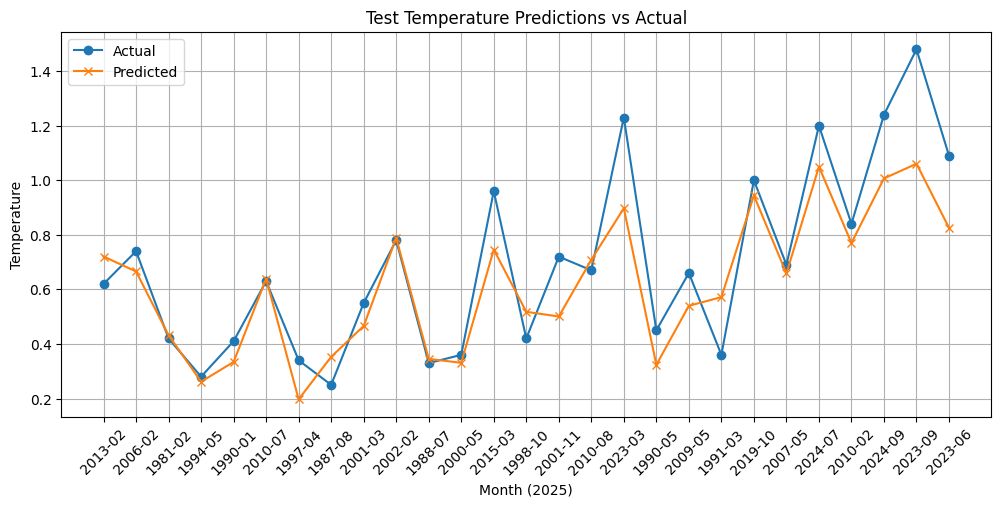

In [ ]:
plot_predictions(y_true, y_pred,list_test_dates, title="Test Set")

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error
from scipy import stats

def analyze_residuals(y_true, y_pred, title="Residual Analysis"):
    """
    Compute R² and create comprehensive residual analysis plots.

    Args:
        y_true: Array of true values
        y_pred: Array of predicted values
        title: Title for the plots

    Returns:
        metrics: Dictionary with R², MAE, RMSE, and residual statistics
    """
    # Convert to numpy arrays if needed
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Compute residuals
    residuals = y_true - y_pred

    # Compute metrics
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = np.mean(residuals**2)
    rmse = np.sqrt(mse)
    residual_mean = np.mean(residuals)
    residual_std = np.std(residuals)

    metrics = {
        'r2': r2,
        'mae': mae,
        'mse': mse,
        'rmse': rmse,
        'residual_mean': residual_mean,
        'residual_std': residual_std
    }

    # Create visualizations
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # 1. Predictions vs Actual (scatter)
    ax1 = axes[0, 0]
    ax1.scatter(y_true, y_pred, alpha=0.6, edgecolors='k', linewidth=0.5)

    # Perfect prediction line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

    ax1.set_xlabel('Actual Values', fontsize=12)
    ax1.set_ylabel('Predicted Values', fontsize=12)
    ax1.set_title(f'{title}\nPredictions vs Actual (R² = {r2:.4f})', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Add metrics text box
    textstr = f'RMSE: {rmse:.4f}\nMAE: {mae:.4f}\nR²: {r2:.4f}'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    ax1.text(0.05, 0.95, textstr, transform=ax1.transAxes, fontsize=10,
             verticalalignment='top', bbox=props)

    # 2. Residuals vs Predicted
    ax2 = axes[0, 1]
    ax2.scatter(y_pred, residuals, alpha=0.6, edgecolors='k', linewidth=0.5)
    ax2.axhline(y=0, color='r', linestyle='--', lw=2, label='Zero Residual')
    ax2.axhline(y=residual_mean, color='orange', linestyle='--', lw=1.5,
                label=f'Mean: {residual_mean:.4f}')

    # Add ±2 std lines
    ax2.axhline(y=2*residual_std, color='green', linestyle=':', lw=1, alpha=0.7,
                label=f'±2σ: ±{2*residual_std:.4f}')
    ax2.axhline(y=-2*residual_std, color='green', linestyle=':', lw=1, alpha=0.7)

    ax2.set_xlabel('Predicted Values', fontsize=12)
    ax2.set_ylabel('Residuals', fontsize=12)
    ax2.set_title('Residual Plot', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # 3. Residual Distribution (histogram + normal fit)
    ax3 = axes[1, 0]
    ax3.hist(residuals, bins=30, density=True, alpha=0.7, color='skyblue', edgecolor='black')

    # Fit normal distribution
    mu, sigma = stats.norm.fit(residuals)
    x = np.linspace(residuals.min(), residuals.max(), 100)
    ax3.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=2,
             label=f'Normal fit\nμ={mu:.4f}, σ={sigma:.4f}')

    ax3.axvline(x=0, color='green', linestyle='--', lw=2, label='Zero')
    ax3.set_xlabel('Residuals', fontsize=12)
    ax3.set_ylabel('Density', fontsize=12)
    ax3.set_title('Residual Distribution', fontsize=14, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # 4. Q-Q Plot (normality check)
    ax4 = axes[1, 1]
    stats.probplot(residuals, dist="norm", plot=ax4)
    ax4.set_title('Q-Q Plot (Normality Check)', fontsize=14, fontweight='bold')
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print metrics
    print("\n" + "="*60)
    print(f"{title.upper()} - METRICS")
    print("="*60)
    print(f"R² Score:          {r2:.6f}")
    print(f"RMSE:              {rmse:.6f}")
    print(f"MAE:               {mae:.6f}")
    print(f"MSE:               {mse:.6f}")
    print(f"\nResidual Mean:     {residual_mean:.6f}")
    print(f"Residual Std:      {residual_std:.6f}")
    print("="*60 + "\n")

    return metrics, residuals

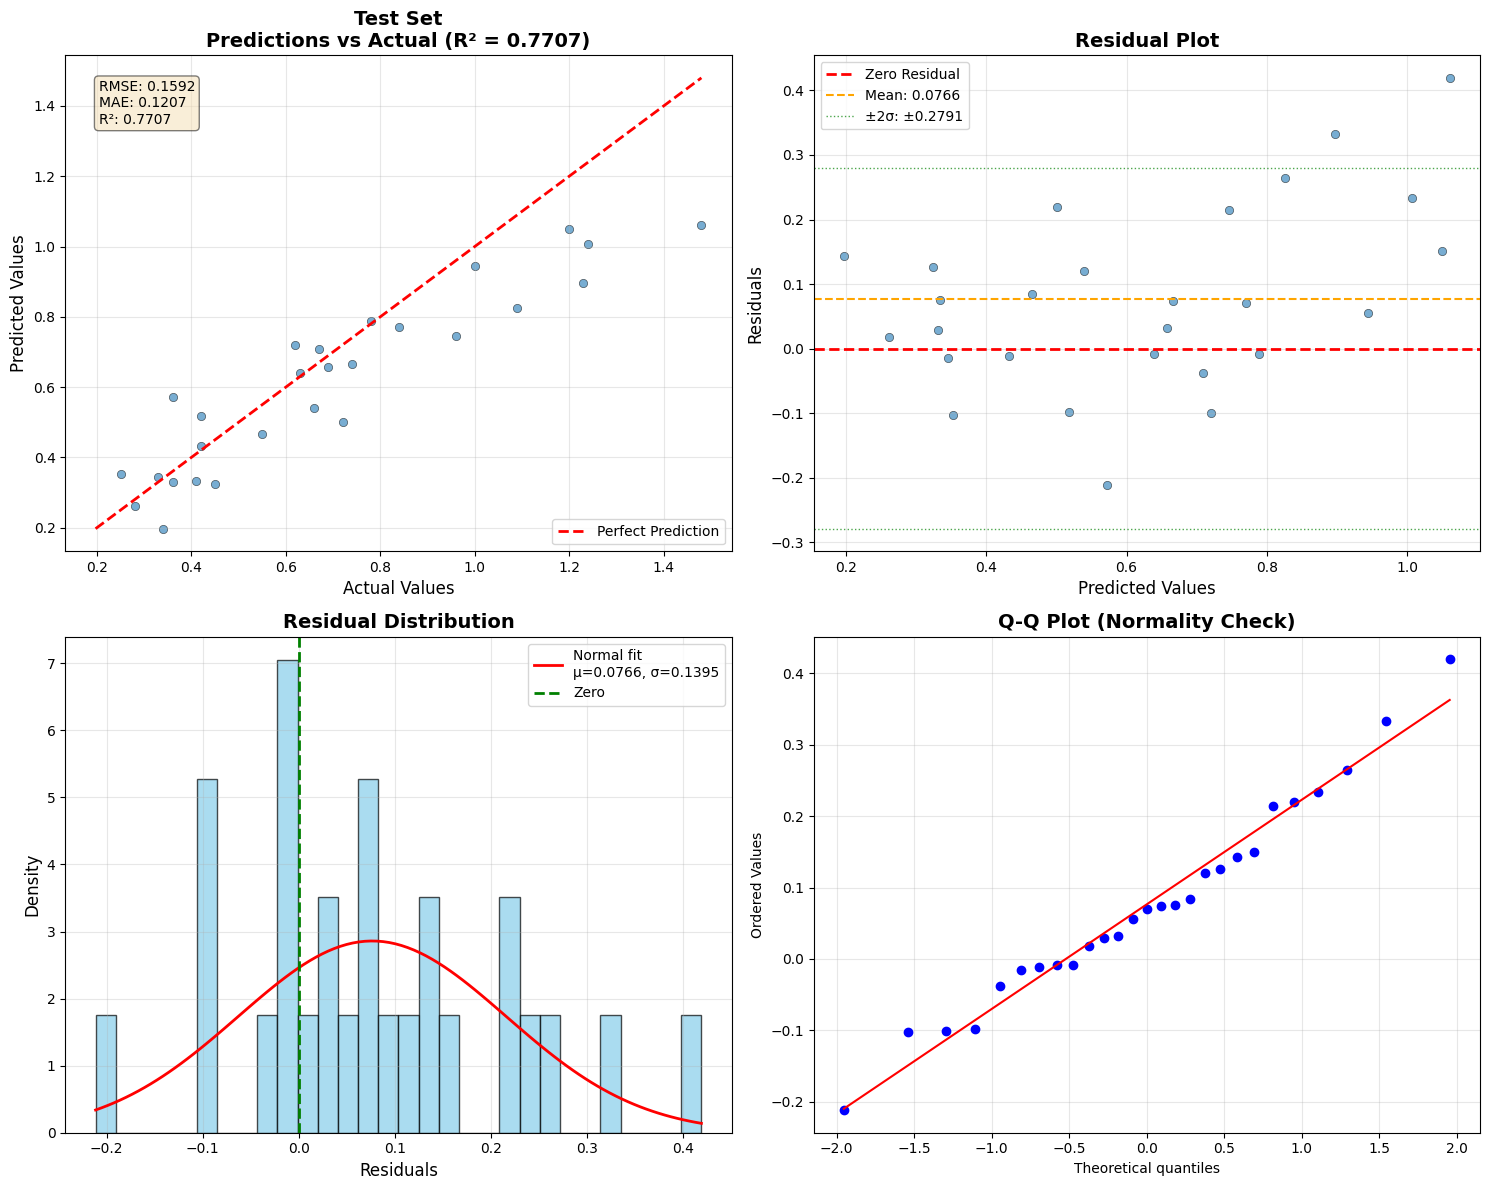


TEST SET - METRICS
R² Score:          0.770749
RMSE:              0.159169
MAE:               0.120688
MSE:               0.025335

Residual Mean:     0.076557
Residual Std:      0.139548



In [ ]:
##Analyze residuals and get R² + plots
metrics, residuals = analyze_residuals(y_true, y_pred, title="Test Set")


## Evaluate on the last year

In [ ]:
test_2025_loader.dataset.month_years

array(['2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06',
       '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12'],
      dtype='<U7')

Test loss: 0.105090
Mse: 0.105090


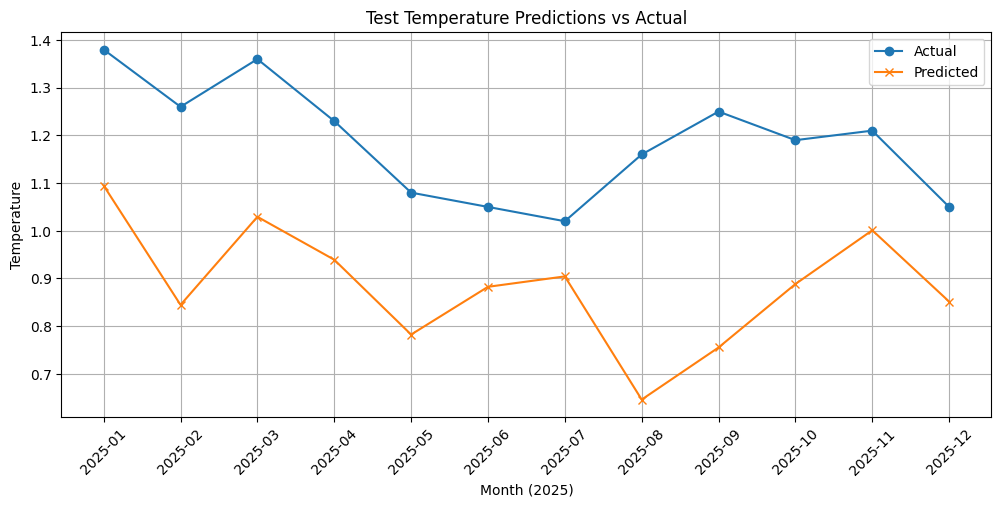

In [ ]:
## TESTING
list_test_dates = [str(s) for s in test_2025_loader.dataset.month_years]


# Reload the mpodel's arameters of the best performing model (lowest validation loss)
model.load_state_dict(th.load(checkpoints_dir / "model_checkpoint.pth")["model_state_dict"])
model.to(device)

test_loss25, test_mse25, (y_true25, y_pred25) = evaluate_model(model,
                                                       test_2025_loader,
                                                       criterion,
                                                      device,
                                                       use_mask=True)

print(f"Test loss: {test_loss25:.6f}")
print(f"Mse: {test_mse25:.6f}")


## plot
plot_predictions(y_true25, y_pred25,list_test_dates, title="2025 Set")




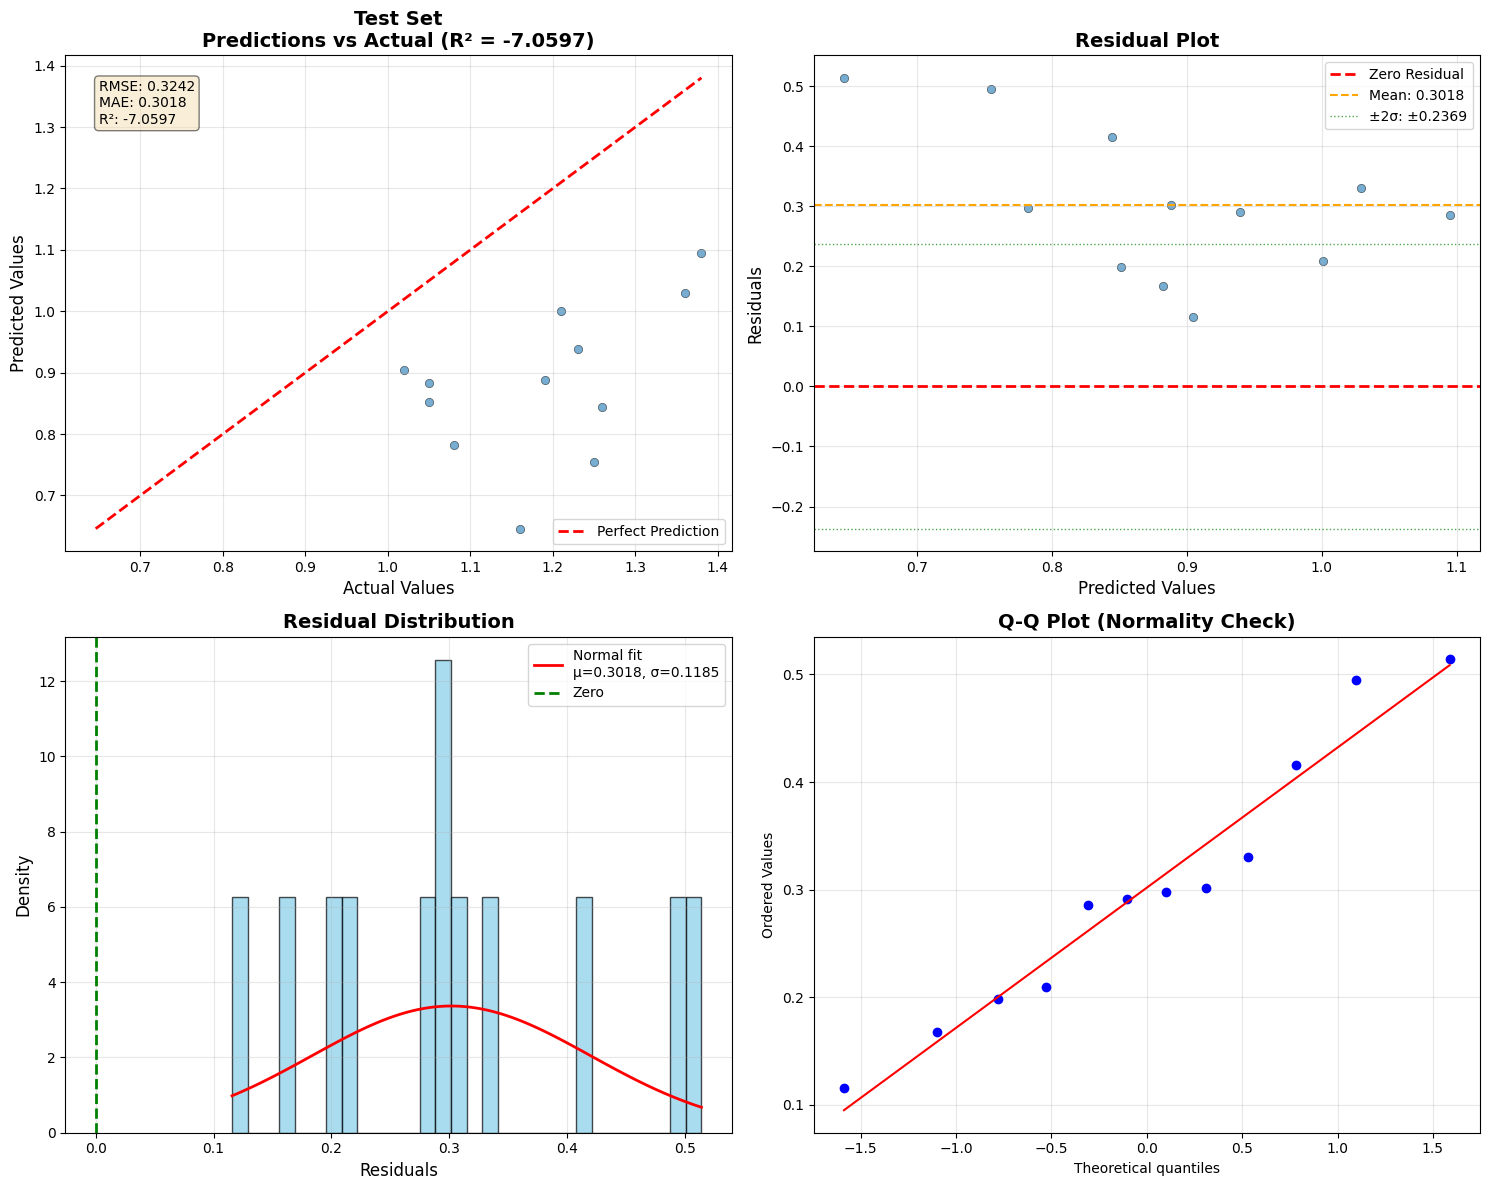


TEST SET - METRICS
R² Score:          -7.059738
RMSE:              0.324176
MAE:               0.301759
MSE:               0.105090

Residual Mean:     0.301759
Residual Std:      0.118454



In [ ]:
##Analyze residuals and get R² + plots
metrics, residuals = analyze_residuals(y_true25, y_pred25, title="Test Set")

## Fine Tunning model

Fine tunnel the model with data from ECMWFS

Time series is only 5 years

In [ ]:
## get the mean and std of the ERA5 dataset
dataset_era5 = TempDSMask('/content/drive/MyDrive/Copernicus_lab/NASA-TEMP-LAND-OCEAR-1981-2025/era5-1981-2025-temp-clean.npz')

mu, std = dataset_era5.return_mu_std()

Dataset loaded from /content/drive/MyDrive/Copernicus_lab/NASA-TEMP-LAND-OCEAR-1981-2025/era5-1981-2025-temp-clean.npz:
  - Samples: 528
  - Capitals: 117
  - Timepoints: 31
  - Shape: (528, 117, 31)


In [ ]:
mu

tensor([[27.8728, 27.8995, 27.9220,  ..., 26.4927, 25.9933, 16.2086],
        [26.5950, 26.6236, 26.6233,  ..., 24.7432, 24.1328, 15.4350],
        [15.3964, 15.4354, 15.4622,  ..., 14.3819, 14.0103,  8.9287],
        ...,
        [-8.1118, -8.4231, -8.4089,  ..., -6.4760, -5.9567, -4.9139],
        [ 9.5113,  9.4142,  9.2879,  ...,  9.4466,  9.5012,  5.5762],
        [12.0026, 12.0705, 12.2501,  ..., 11.5947, 11.3469,  6.8595]])

In [ ]:
#3 config
# Configuration
config = {
    'model_name': 'YearInjection',
    'in_channels': 117,
    'n_classes': 1,
    'dropout': 0.4,
    'learning_rate': 1e-3,
    'batch_size': 32,
    'n_epochs': 75,
    'use_mask': True,
    'freeze_until_layer':'conv2',
    'freeze_early_layers': False,
    'verbose': True
}

## dataloader
### DATASET DATALOADER
# Load dataset
path_openmeteo_dataset = '/content/drive/MyDrive/Copernicus_lab/NASA-TEMP-LAND-OCEAR-1981-2025/openmeteo-2025-temp.npz'
dataset = TempDSMask_Finetun(path_openmeteo_dataset,
                            return_mask=True,
                             mu = mu,
                             std=std)

# Split into train/val/test
train_size = int(0.80 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED_VALUE)
)

## DATALOADER
# Create dataloaders
train_loader = DataLoader(train_dataset,
                          batch_size=config['batch_size'],
                          shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], shuffle=False)
##test_dataloader = DataLoader(test_dataset, batch_size=config['batch_size'], shuffle=False)

## another TEST DATASET - ONLY 2025
##dataset_2025 = dataset.get_2025_dataset()
##test_2025_loader = DataLoader(dataset_2025, batch_size=config['batch_size'], shuffle=False)


# Test it
print(f"Train size: {len(train_dataset)}")
print(f"Val size: {len(val_dataset)}")
#print(f"Test size:{len(test_dataset)}")
##print(f"2025 holdout size: {len(dataset_2025)}")

Dataset loaded from /content/drive/MyDrive/Copernicus_lab/NASA-TEMP-LAND-OCEAR-1981-2025/openmeteo-2025-temp.npz:
  - Samples: 72
  - Capitals: 117
  - Timepoints: 31
  - Shape: (72, 117, 31)
Train size: 57
Val size: 15


In [ ]:
## create a new directory to save the model weights
checkpoints_dir_fine =Path('fine_tunning_checkpoints')
os.makedirs(name = checkpoints_dir_fine, exist_ok=True)

# Set up the device to train the model to GPU by default if it is avaible, otherwise CPU
device = th.device("cuda" if th.cuda.is_available() else "cpu")
print("Device: ", device)

# Load the pre-trained model
pretrained_model_path = os.path.join(checkpoints_dir / "model_checkpoint.pth")

checkpoint = torch.load(pretrained_model_path, map_location=device)

# Initialize model
model = MaskTempCNN(in_channels=117, n_classes=1, dropout=config['dropout'])
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)

print(f"Loaded pre-trained model from epoch {checkpoint['epoch']}")
print(f"Pre-trained validation loss: {checkpoint['val_loss']:.6f}")

if config['freeze_early_layers'] or config['freeze_until_layer']:
  layers_to_freeze = []

  if config['freeze_until_layer']:
      # Freeze specific layers up to a point
      freeze_map = {
          'conv1': ['conv1'],
          'conv2': ['conv1', 'conv2'],
          'conv3': ['conv1', 'conv2', 'conv3'],
          'conv4': ['conv1', 'conv2', 'conv3', 'conv4'],
      }
      layers_to_freeze = freeze_map.get(config['freeze_until_layer'], [])
  elif config['freeze_early_layers']:
      # Default: freeze first two conv layers
      layers_to_freeze = ['conv1', 'conv2']

  for layer_name in layers_to_freeze:
      layer = getattr(model, layer_name)
      for param in layer.parameters():
          param.requires_grad = False
      if config['verbose']:
          print(f"Froze layer: {layer_name}")

# Count trainable parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
if config['verbose']:
  print(f"Trainable parameters: {trainable_params:,} / {total_params:,} "
        f"({100 * trainable_params / total_params:.1f}%)")

# Initialize optimizer with lower learning rate for fine-tuning
optimizer = torch.optim.Adam(
  filter(lambda p: p.requires_grad, model.parameters()),
  lr=config['learning_rate']
)

## new wandb config
wandb_config = {}
wandb_config.update({
    'fine_tuning': True,
    'pretrained_model': str(pretrained_model_path),
    'learning_rate': config['learning_rate'],
    'epoch_size':config['n_epochs'],
    'freeze_early_layers': config['freeze_early_layers'],
    'freeze_until_layer': config['freeze_until_layer'],
})

wandb_run_name = f"finetune_{generate_run_name(wandb_config)}"

# Use the existing train_model function
results_epoch_df, results_train_df = train_model(
    model=model,
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    n_epochs=config['n_epochs'],
    resultfolder=checkpoints_dir_fine,
    device=device,
    use_mask=True,
    use_wandb=True,
    wandb_project='temperature-prediction-lstm',
    wandb_config=wandb_config,
    wandb_run_name=wandb_run_name,
    verbose=True
)

Device:  cuda
Loaded pre-trained model from epoch 14
Pre-trained validation loss: 0.012468
Froze layer: conv1
Froze layer: conv2
Trainable parameters: 500,993 / 1,308,417 (38.3%)


wandb run: finetune_LSTM_lr1e-05_20260210_162057
wandb url: https://wandb.ai/emanuelgoulartf-paris-lodron-universit-t-salzburg/temperature-prediction-lstm/runs/ljpx7g5n
Epoch 0 (initial): train loss=0.51222, train MSE=0.545374, val loss=0.621801, val MSE=0.621941
Epoch 1: train loss=0.379267, train MSE=0.379267, val loss=0.356978, val MSE=0.355171
  → Best model saved (val_loss: 0.356978)
Epoch 2: train loss=0.378874, train MSE=0.378874, val loss=0.267321, val MSE=0.266505
  → Best model saved (val_loss: 0.267321)
Epoch 3: train loss=0.404241, train MSE=0.404241, val loss=0.263176, val MSE=0.263038
  → Best model saved (val_loss: 0.263176)
Epoch 4: train loss=0.331876, train MSE=0.331876, val loss=0.23911, val MSE=0.239264
  → Best model saved (val_loss: 0.23911)
Epoch 5: train loss=0.359423, train MSE=0.359423, val loss=0.232962, val MSE=0.233026
  → Best model saved (val_loss: 0.232962)
Epoch 6: train loss=0.342156, train MSE=0.342156, val loss=0.256606, val MSE=0.256855
Epoch 7: tra

epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇█
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,█▆▅▅▄▄▅▃▄▃▃▃▄▂▂▂▂▄▃▃▂▃▂▂▃▂▂▂▂▁▂▂▂▂▂▁▁▁▁▁
train_mse,█▅▆▅▄▅▄▅▄▃▃▃▃▃▂▃▂▂▂▂▃▂▂▁▂▂▁▂▂▁▁▁▂▁▁▁▁▂▁▁
val_loss,█▆▆▅▆▅▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▂▂▁▁▁▁▁▁▁▁▁▁
val_mse,█▆▅▆▆▅▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▂▂▁▁▂▁▁▁▁▁▁▁▁▁
best_epoch,72
best_val_loss,0.01567
best_val_mse,0.01521
epoch,75
learning_rate,1e-05


## Predict !

Predict the temperature anomaly for the month of january

In [ ]:
## load the tensor of temperatures for jan/2026
jan_2026_path = '/content/drive/MyDrive/Copernicus_lab/NASA-TEMP-LAND-OCEAR-1981-2025/openmeteo-jan26.npz'
tt = np.load(jan_2026_path, allow_pickle=True)

tm = tt['temp_matrices']
tm_mask = tt['masks']

tm = tm *tm_mask

## normalize
tt = torch.tensor(tm, dtype=torch.float32)
tts = (tt - mu) / (std + 1e-8)  # Add epsilon to avoid division by zero

result = model(tts.to(device))
print(result)

In [ ]:
tt['capitals']

array(['abu dhabi', 'abuja', 'addis ababa', 'algiers', 'amman',
       'amsterdam', 'andorra la vella', 'ankara', 'antananarivo',
       'ashgabat', 'astana', 'athens', 'bangkok', 'beijing', 'beirut',
       'belgrade', 'berlin', 'bern', 'bishkek', 'bogota', 'bordeaux',
       'brasilia', 'bratislava', 'brazzaville', 'brussels', 'bucharest',
       'budapest', 'buenos aires', 'cairo', 'calafate', 'canberra',
       'caracas', 'copenhagen', 'dakar', 'doha', 'dublin',
       'florianopolis', 'gold coast', 'guatemala city', 'hanoi', 'harare',
       'havana', 'helsinki', 'hong kong', 'jakarta', 'jerusalem',
       'kathmandu', 'kiev', 'kingston', 'kinshasa', 'kuala lumpur',
       'lima', 'lisbon', 'ljubljana', 'london', 'luanda',
       'luxembourg city', 'madrid', 'managua', 'manila', 'maputo',
       'milan', 'minsk', 'monaco', 'montevideo', 'moscow', 'munich',
       'nairobi', 'napoli', 'nicosia', 'oslo', 'ottawa', 'panama city',
       'paris', 'podgorica', 'port louis', 'port of sp

In [ ]:
tm = tt['temp_matrices']
tm_mask = tt['masks']

tm = tm *tm_mask

## normalize
tt = torch.tensor(tm, dtype=torch.float32)
tts = (tt - mu) / (std + 1e-8)  # Add epsilon to avoid division by zero


In [ ]:
tts

tensor([[[-1.3903, -1.4579, -1.0198,  ..., -0.7329, -0.6639, -1.1140],
         [ 1.3950,  1.0494,  1.4157,  ...,  0.6556,  0.6966, -1.1708],
         [-1.0307, -1.0606, -1.5689,  ...,  0.4704,  0.4095, -1.1661],
         ...,
         [-0.9017, -1.1816, -1.4725,  ..., -1.1306, -1.3061,  0.2845],
         [-1.2957, -1.8563, -1.7492,  ..., -1.1703, -0.9149, -0.5791],
         [-0.8865, -1.2543, -1.4251,  ..., -0.8807, -0.8997, -0.7601]]])

In [ ]:
model(tts.to(device))

tensor([[0.9876]], device='cuda:0', grad_fn=<AddmmBackward0>)

# New Models

### Time Feature Injection

In [ ]:

class YearInjection(nn.Module):
    def __init__(self, in_channels, n_classes, dropout):
        super().__init__()
        self.in_channels = in_channels
        self.n_classes = 1
        self.dropout = dropout

        # --- Convolutional Backbone ---
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels, 256, kernel_size=5, padding='same'),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Dropout(p=self.dropout)
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(256, 512, kernel_size=5, padding='same'),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Dropout(p=self.dropout)
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(512, 256, kernel_size=3, padding='same'),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Dropout(p=self.dropout)
        )
        self.conv4 = nn.Sequential(
            nn.Conv1d(256, 128, kernel_size=3, padding='same'),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Dropout(p=self.dropout)
        )

        # --- Fully Connected Head ---
        # Note: input is now 128 (CNN features) + 1 (Year feature)
        self.fc1 = nn.Sequential(
            nn.Linear(128 + 1, 64),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Dropout(p=self.dropout)
        )
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x, year, mask=None):
        """
        x: (batch, 117, 31)
        year: (batch, 1) - Raw year values (e.g., 2025)
        mask: (batch, 117, 31)
        """
        # 1. Apply mask
        if mask is not None:
            x = x * mask

        # 2. Forward through Convolutions
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)

        # 3. Global Pooling (Mask-aware)
        if mask is not None:
            mask_pooled = torch.mean(mask, dim=1, keepdim=True)
            valid_count = mask_pooled.sum(dim=2, keepdim=True).clamp(min=1)
            x = (x * mask_pooled).sum(dim=2) / valid_count.squeeze(-1)
        else:
            x = torch.mean(x, dim=2)

        # 4. Normalize Year and Inject
        # Normalizing to [0, 1] range based on your data span (1980-2026)
        # This prevents the raw '2025' value from overwhelming the weights
        year_norm = (year - 1981) / (2028 - 1981)

        # Concatenate: (batch, 128) + (batch, 1) -> (batch, 129)
        x = torch.cat((x, year_norm), dim=1)

        # 5. Final Regression
        x = self.fc1(x)
        x = self.fc2(x)

        return x

In [ ]:
class YearTempDSMask(Dataset):
    def __init__(self, npz_path,
                 return_mask=True,
                 exclude_2025=True):
        self.exclude_2025 = exclude_2025
        self.return_mask = return_mask

        data = np.load(npz_path, allow_pickle=True)
        split_idx = -12 if exclude_2025 else None

        self.temp_matrices_n = data['temp_matrices'][:split_idx]
        self.masks = data['masks'][:split_idx]
        self.labels = data['labels'][:split_idx]
        self.month_years = data['month_years'][:split_idx]
        self.capitals = data['capitals'].astype(str)

        # 1. Parse Years from metadata (assuming month_years is e.g., "2024-05" or contains year as int/str)
        # We convert them to floats immediately for the model
        self.years = self._extract_years(self.month_years)

        self.temp_matrices_2025_n = data['temp_matrices'][-12:]
        self.masks_2025 = data['masks'][-12:]
        self.labels_2025 = data['labels'][-12:]
        self.month_years_2025 = data['month_years'][-12:]
        self.years_2025 = self._extract_years(self.month_years_2025)

        self.mu, self.std = self._compute_stats(self.temp_matrices_n)
        self.temp_matrices = self._normalize(self.temp_matrices_n, self.mu, self.std)
        self.temp_matrices_2025 = self._normalize(self.temp_matrices_2025_n, self.mu, self.std)

        print(f"Dataset loaded. Year range: {self.years.min()} to {self.years.max()}")

    def _extract_years(self, month_years_array):
        """
        Extracts numerical year from the month_year format.
        Adjust the logic if your month_years format is different (e.g. integer or datetime).
        """
        # If strings like "2025-01", take first 4 chars. If already numeric, just cast.
        years = [float(str(my)[:4]) for my in month_years_array]
        return np.array(years, dtype=np.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = torch.FloatTensor(self.temp_matrices[idx])
        y = torch.tensor([self.labels[idx]], dtype=torch.float32)
        year = torch.tensor([self.years[idx]], dtype=torch.float32)

        if self.return_mask:
            mask = torch.FloatTensor(self.masks[idx])
            return x, y, mask, year # Added year as 4th return element

        return x, y, year

    def _compute_stats(self, temp_matrices):
        tt = torch.tensor(temp_matrices, dtype=torch.float32)
        mu = tt.mean(dim=0)
        std = tt.std(dim=0)
        return mu, std

    def _normalize(self, temp_matrices, mu, std):
        tt = torch.tensor(temp_matrices, dtype=torch.float32)
        tts = (tt - mu) / (std + 1e-8)
        return tts.numpy()

    def return_mu_std(self):
      return self.mu, self.std

    def get_month_year(self, idx):
        return self.month_years[idx]

    def get_2025_dataset(self):
        return TempDS2025(
            temp_matrices=self.temp_matrices_2025,
            masks=self.masks_2025,
            labels=self.labels_2025,
            month_years=self.month_years_2025,
            years=self.years_2025, # Pass extracted years
            return_mask=self.return_mask
        )

class TempDS2025(Dataset):
    def __init__(self, temp_matrices, masks, labels, month_years, years, return_mask=True):
        self.temp_matrices = temp_matrices
        self.masks = masks
        self.labels = labels
        self.month_years = month_years
        self.years = years
        self.return_mask = return_mask

    def __len__(self):
        return len(self.labels)

    def get_month_year(self,idx):
      return self.month_years[idx]

    def __getitem__(self, idx):
        x = torch.FloatTensor(self.temp_matrices[idx])
        y = torch.tensor([self.labels[idx]], dtype=torch.float32)
        year = torch.tensor([self.years[idx]], dtype=torch.float32)

        if self.return_mask:
            mask = torch.FloatTensor(self.masks[idx])
            return x, y, mask, year

        return x, y, year



class YearTempDSMask_Finetun(Dataset):
    def __init__(self, npz_path, return_mask=True,  mu=None, std=None):
        """
        Load precomputed temperature data from npz file.

        Args:
            npz_path: Path to the .npz file
            return_mask: Whether to return mask along with data
            exclude_2025: Wether exclude 2025 or not
            mu:tensor  - mean - Same mean and std used for training
            std:tensor - std - Same mean and std used for training
            std: std
        """
        self.return_mask = return_mask
        self.mu = mu
        self.std = std
        if mu is None or std is None:
            raise ValueError("mu and std must be provided for normalization")

        # Load all data at once
        data = np.load(npz_path,
                        allow_pickle=True,
                       )



        self.temp_matrices_n = data['temp_matrices']  # (n_samples, n_capitals, n_timepoints) ## non normalized
        self.masks = data['masks'] # (n_samples, n_capitals, n_timepoints)
        self.labels = data['labels'] # (n_samples,)
        self.month_years = data['month_years'] # (n_samples,)
        self.capitals = data['capitals'].astype(str)  # (n_capitals,)

        self.years = self._extract_years(self.month_years)

        # Normalize using ONLY the training data statistics (important!)
        self.temp_matrices = self._normalize(self.temp_matrices_n, self.mu, self.std)


        ## exclude the last year - 2025 for testing
        print(f"Dataset loaded from {npz_path}:")
        print(f"  - Samples: {len(self.labels)}")
        print(f"  - Capitals: {len(self.capitals)}")
        print(f"  - Timepoints: {self.temp_matrices.shape[2]}")
        print(f"  - Shape: {self.temp_matrices.shape}")
        print(f"Dataset loaded. Year range: {self.years.min()} to {self.years.max()}")

    def _extract_years(self, month_years_array):
        """
        Extracts numerical year from the month_year format.
        Adjust the logic if your month_years format is different (e.g. integer or datetime).
        """
        # If strings like "2025-01", take first 4 chars. If already numeric, just cast.
        years = [float(str(my)[:4]) for my in month_years_array]
        return np.array(years, dtype=np.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = self.temp_matrices[idx]  # shape: (n_capitals, n_timepoints)
        y = self.labels[idx]          # scalar
        year = torch.tensor([self.years[idx]], dtype=torch.float32)

        if self.return_mask:
            mask = torch.FloatTensor(self.masks[idx])
            return x, np.array(y).reshape(-1), mask, year

        return x, y, year

    def get_month_year(self, idx):
        """Helper to get month_year for a given index"""
        return self.month_years[idx]

    def _normalize(self, temp_matrices, mu, std):
        """Normalize using provided mean and std"""
        tt = torch.tensor(temp_matrices, dtype=torch.float32)
        tts = (tt - mu) / (std + 1e-8)  # Add epsilon to avoid division by zero
        return tts.numpy()






In [ ]:
def train_epoch(model, loader, criterion, optimizer, device: str ='cuda',use_mask=True):

    losses = []
    mse_scores = []

    # TODO: call the function to set the training mode
    model.train()

    for batch in loader:
      if use_mask:
          x, y, mask, year = batch
          x, y, mask, year = x.to(device), y.to(device), mask.to(device), year.to(device)
      else:
          x, y , year= batch[:2]  # In case batch has mask but we don't use it
          x, y , year= x.to(device), y.to(device), year.to(device)
          mask = None

        ## zero gradients
      optimizer.zero_grad()

        ## forward
        # Forward pass (pass mask if model supports it)
      if use_mask and mask is not None:
          outputs = model(x, year, mask=mask)
      else:
          outputs = model(x, year)

        ## loss
      loss = criterion(outputs.squeeze(), y.squeeze())

        ##
      loss.backward()

        ## update optimizer
      optimizer.step()

      with torch.no_grad():
        losses.append(loss.detach().item())

        y_true = y.cpu().numpy().flatten()
        y_pred = outputs.detach().cpu().numpy().flatten()

        mse = mean_squared_error(y_true, y_pred)
        mse_scores.append(mse)

    return losses, mse_scores

def evaluate_model(model, loader, criterion, device: str ='cuda',use_mask=True):

    total_loss = 0

    yTrue = []
    yPred = []

    ##eval
    model.eval()

    with torch.no_grad():
        for batch in loader:
          if use_mask:
                x, y, mask, year = batch
                x, y, mask, year = x.to(device), y.to(device), mask.to(device), year.to(device)
          else:
                x, y = batch[:2]
                x, y = x.to(device), y.to(device)
                mask = None

          ## output
          # Forward pass
          if use_mask and mask is not None:
             outputs = model(x, year, mask=mask)
          else:
             outputs = model(x)

          ## loss
          loss= criterion(outputs.squeeze(), y.squeeze())
          total_loss += loss.item()

          yTrue.extend(y.cpu().numpy().flatten())
          yPred.extend(outputs.cpu().numpy().flatten())


    # TODO: Average the loss
    avg_loss = total_loss / len(loader)

    #Compute the MSE SCORE
    mse_score = mean_squared_error(yTrue, yPred)
    mae_score = mean_absolute_error(yTrue, yPred)

    # TODO: Return loss, mse_ , predict
    return avg_loss, mse_score, (yTrue, yPred)


def train_model(model, train_dataloader, val_dataloader, criterion, optimizer,
                n_epochs, resultfolder, device, use_mask=True, use_wandb=True,
                wandb_project=None, wandb_config=None,wandb_run_name=None, verbose=True):
    """
    Train model with optional wandb logging.

    Args:
        model: PyTorch model
        train_dataloader: Training data loader
        val_dataloader: Validation data loader
        criterion: Loss function
        optimizer: Optimizer
        n_epochs: Number of epochs
        resultfolder: Path to save checkpoints
        device: Device to train on
        use_mask: Whether to use mask in forward pass
        use_wandb: Whether to log to wandb
        wandb_project: Wandb project name
        wandb_config: Dict of config parameters to log
        verbose: Print training progress
    """

    # Initialize wandb
    if use_wandb:
        # Generate unique run name if not provided
        if wandb_run_name is None and wandb_config is not None:
            wandb_run_name = generate_run_name(wandb_config)

        wandb.init(
            project=wandb_project or "temperature-lstm",
            name=wandb_run_name,
            config=wandb_config or {},
            reinit=True
        )

        # Log model architecture
        wandb.watch(model, log='all', log_freq=100)

        if verbose:
            print(f"wandb run: {wandb.run.name}")
            print(f"wandb url: {wandb.run.url}")

    # Prepare DataFrames to store metrics
    columns = ['train_loss', 'train_mse', 'val_loss', 'val_mse']
    results_epoch_df = pd.DataFrame(columns=columns)
    results_train_df = pd.DataFrame(columns=columns[:2])

    # Initial evaluation before training
    train_loss, train_mse, _ = evaluate_model(model, train_dataloader, criterion, device, use_mask)
    val_loss, val_mse, _ = evaluate_model(model, val_dataloader, criterion, device, use_mask)
    results_epoch_df.loc[0] = [train_loss, train_mse, val_loss, val_mse]

    best_val_loss = val_loss
    best_epoch = 0

    if verbose:
        print(f"Epoch 0 (initial): train loss={np.round(train_loss, 6)}, train MSE={np.round(train_mse, 6)}, "
              f"val loss={np.round(val_loss, 6)}, val MSE={np.round(val_mse, 6)}")

    # Log initial metrics to wandb
    if use_wandb:
        wandb.log({
            "epoch": 0,
            "train_loss": train_loss,
            "train_mse": train_mse,
            "val_loss": val_loss,
            "val_mse": val_mse,
        })

    # Training loop
    for epoch in range(1, n_epochs + 1):
        # Train for one epoch
        train_losses, train_mse_scores = train_epoch(
            model, train_dataloader, criterion, optimizer, device, use_mask
        )

        # Evaluate on validation set
        val_loss, val_mse, _ = evaluate_model(
            model, val_dataloader, criterion, device, use_mask
        )

        # Store results
        avg_train_loss = np.mean(train_losses)
        avg_train_mse = np.mean(train_mse_scores)

        results_epoch_df.loc[epoch] = [avg_train_loss, avg_train_mse, val_loss, val_mse]
        results_train_df.loc[epoch] = [train_losses, train_mse_scores]

        # Log to wandb
        if use_wandb:
            wandb.log({
                "epoch": epoch,
                "train_loss": avg_train_loss,
                "train_mse": avg_train_mse,
                "val_loss": val_loss,
                "val_mse": val_mse,
                "learning_rate": optimizer.param_groups[0]['lr'],
            })

        if verbose:
            print(f"Epoch {epoch}: train loss={np.round(avg_train_loss, 6)}, train MSE={np.round(avg_train_mse, 6)}, "
                  f"val loss={np.round(val_loss, 6)}, val MSE={np.round(val_mse, 6)}")

        # Save best model based on validation loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            save_model(model, optimizer, epoch, resultfolder, val_loss)

            if use_wandb:
                wandb.run.summary["best_epoch"] = best_epoch
                wandb.run.summary["best_val_loss"] = best_val_loss
                wandb.run.summary["best_val_mse"] = val_mse

            if verbose:
                print(f"  → Best model saved (val_loss: {np.round(val_loss, 6)})")

    if verbose:
        print(f"\nTraining completed. Best model from epoch {best_epoch} with val_loss={np.round(best_val_loss, 6)}")

    # Finish wandb run
    if use_wandb:
        wandb.finish()

    return results_epoch_df, results_train_df


### RUN

In [ ]:
from datetime import datetime
## INITIALISATION

checkpoints_dir =Path('year_checkpoints')
os.makedirs(name = checkpoints_dir, exist_ok=True)

# Set up the device to train the model to GPU by default if it is avaible, otherwise CPU
device = th.device("cuda" if th.cuda.is_available() else "cpu")
print("Device: ", device)

# Configuration
config = {
    'model_name': 'Anomaly_LSTM_Temperature',
    'in_channels': 117,
    'n_classes': 1,
    'dropout': 0.3,
    'learning_rate': 1e-3,
    'batch_size': 32,
    'n_epochs': 100,
    'use_mask': True,
}

#### DATASET DATALOADER
# Load dataset
dataset = YearTempDSMask('/content/content/NASA-TEMP-LAND-OCEAR-1981-2025/era5-1981-2025-temp-clean.npz',
                          return_mask=True,
                         exclude_2025=False)

# Split into train/val/test
total_len = len(dataset)
train_size = int(0.90 * total_len)
val_size = int(0.97 * total_len) # 0.80 to 0.95 is 15%

# Chronological slicing using Subset
train_dataset = torch.utils.data.Subset(dataset, range(0, train_size))
val_dataset = torch.utils.data.Subset(dataset, range(train_size, val_size))
test_dataset = torch.utils.data.Subset(dataset, range(val_size, len(dataset)))

## DATALOADER
train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=config['batch_size'], shuffle=False)

## 2025 HOLDOUT
#dataset_2025 = dataset.get_2025_dataset()
#test_2025_loader = DataLoader(dataset_2025, batch_size=config['batch_size'], shuffle=False)

# Verification
print(f"Train range: {dataset.get_month_year(0)} to {dataset.get_month_year(train_size-1)}")
print(f"Val range:   {dataset.get_month_year(train_size)} to {dataset.get_month_year(val_size-1)}")
print(f"Test range:  {dataset.get_month_year(val_size)} to {dataset.get_month_year(len(dataset)-1)}")
#print(f"2025 range:  {dataset_2025.get_month_year(0)} to {dataset_2025.get_month_year(len(dataset_2025)-1)}")

print(f"Traindataset:{len(train_dataset)}")
print(f"Val:{len(val_dataset)}")
print(f"Test:{len(test_dataset)}")
#### -------------------

Device:  cuda
Dataset loaded. Year range: 1981.0 to 2026.0
Train range: 1981-01 to 2021-06
Val range:   2021-07 to 2024-08
Test range:  2024-09 to 2026-01
Traindataset:486
Val:38
Test:17


In [ ]:

# Define model, criterion, optimizer
model = YearInjection(
    in_channels=config['in_channels'],  # n_capitals
    n_classes=config['n_classes'],
    dropout=config['dropout']
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=config['learning_rate'])


# Train with wandb logging
results_epoch, results_train = train_model(
    model=model,
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    n_epochs=config['n_epochs'],
    resultfolder=checkpoints_dir,
    device=device,
    use_mask=True,  # Enable mask usage
    use_wandb=True,  # Enable wandb logging
    wandb_project="temperature-prediction-lstm",
    wandb_config=config,
    wandb_run_name = generate_run_name(config),
    verbose=True
)

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


wandb run: Anomaly_LSTM_Temperature_lr0.001_20260302_221038
wandb url: https://wandb.ai/emanuelgoulartf-paris-lodron-universit-t-salzburg/temperature-prediction-lstm/runs/8e18rnob
Epoch 0 (initial): train loss=0.506732, train MSE=0.506435, val loss=1.667423, val MSE=1.481039
Epoch 1: train loss=0.122678, train MSE=0.122678, val loss=0.168163, val MSE=0.16029
  → Best model saved (val_loss: 0.168163)
Epoch 2: train loss=0.052824, train MSE=0.052824, val loss=0.101107, val MSE=0.09318
  → Best model saved (val_loss: 0.101107)
Epoch 3: train loss=0.039753, train MSE=0.039753, val loss=0.098336, val MSE=0.086125
  → Best model saved (val_loss: 0.098336)
Epoch 4: train loss=0.031054, train MSE=0.031054, val loss=0.136389, val MSE=0.107215
Epoch 5: train loss=0.038473, train MSE=0.038473, val loss=0.05338, val MSE=0.039645
  → Best model saved (val_loss: 0.05338)
Epoch 6: train loss=0.032107, train MSE=0.032107, val loss=0.080368, val MSE=0.086157
Epoch 7: train loss=0.032327, train MSE=0.03

epoch,▁▁▁▁▂▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇████
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_mse,█▄▃▂▂▂▂▂▃▂▂▂▂▂▂▁▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▄▆▃▄▅▂▇▅▇▂▃▆▆▃▁▁▄▂▁▂▅▄▂▄▁▂▄▁▅▃▄▃▃▂▃▂▁▁▃
val_mse,█▅▆▅▃▃▂▂▅▄▃▃▂▂▂▃▄▁▂▂▂▂▃▂▂▄▃▂▂▃▃▁▂▂▂▃▃▂▂▂
best_epoch,40
best_val_loss,0.00805
best_val_mse,0.01118
epoch,100
learning_rate,0.001


### Test

In [ ]:
## TESTING
# Reload the mpodel's arameters of the best performing model (lowest validation loss)
model.load_state_dict(th.load(checkpoints_dir / "model_checkpoint.pth")["model_state_dict"])
model.to(device)
test_loss, test_mse, (y_true, y_pred) = evaluate_model(model,
                                                       test_dataloader,
                                                       criterion, device,
                                                       use_mask=True)


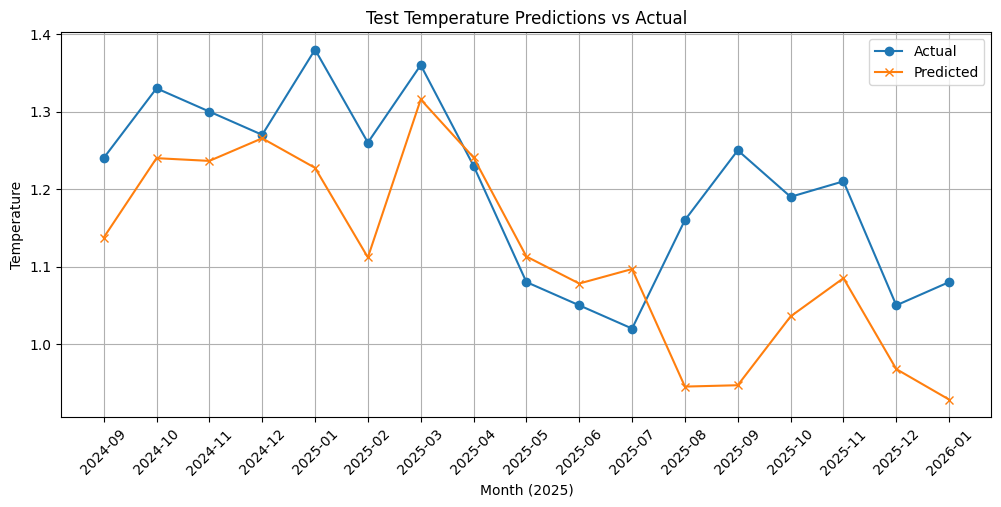

In [ ]:
list_test_dates = []
for dd in test_dataloader.dataset.indices:
  list_test_dates.append(dataset.month_years[dd])

list_test_dates = [str(s) for s in list_test_dates]

plot_predictions(y_true, y_pred,list_test_dates, title="Test Set")

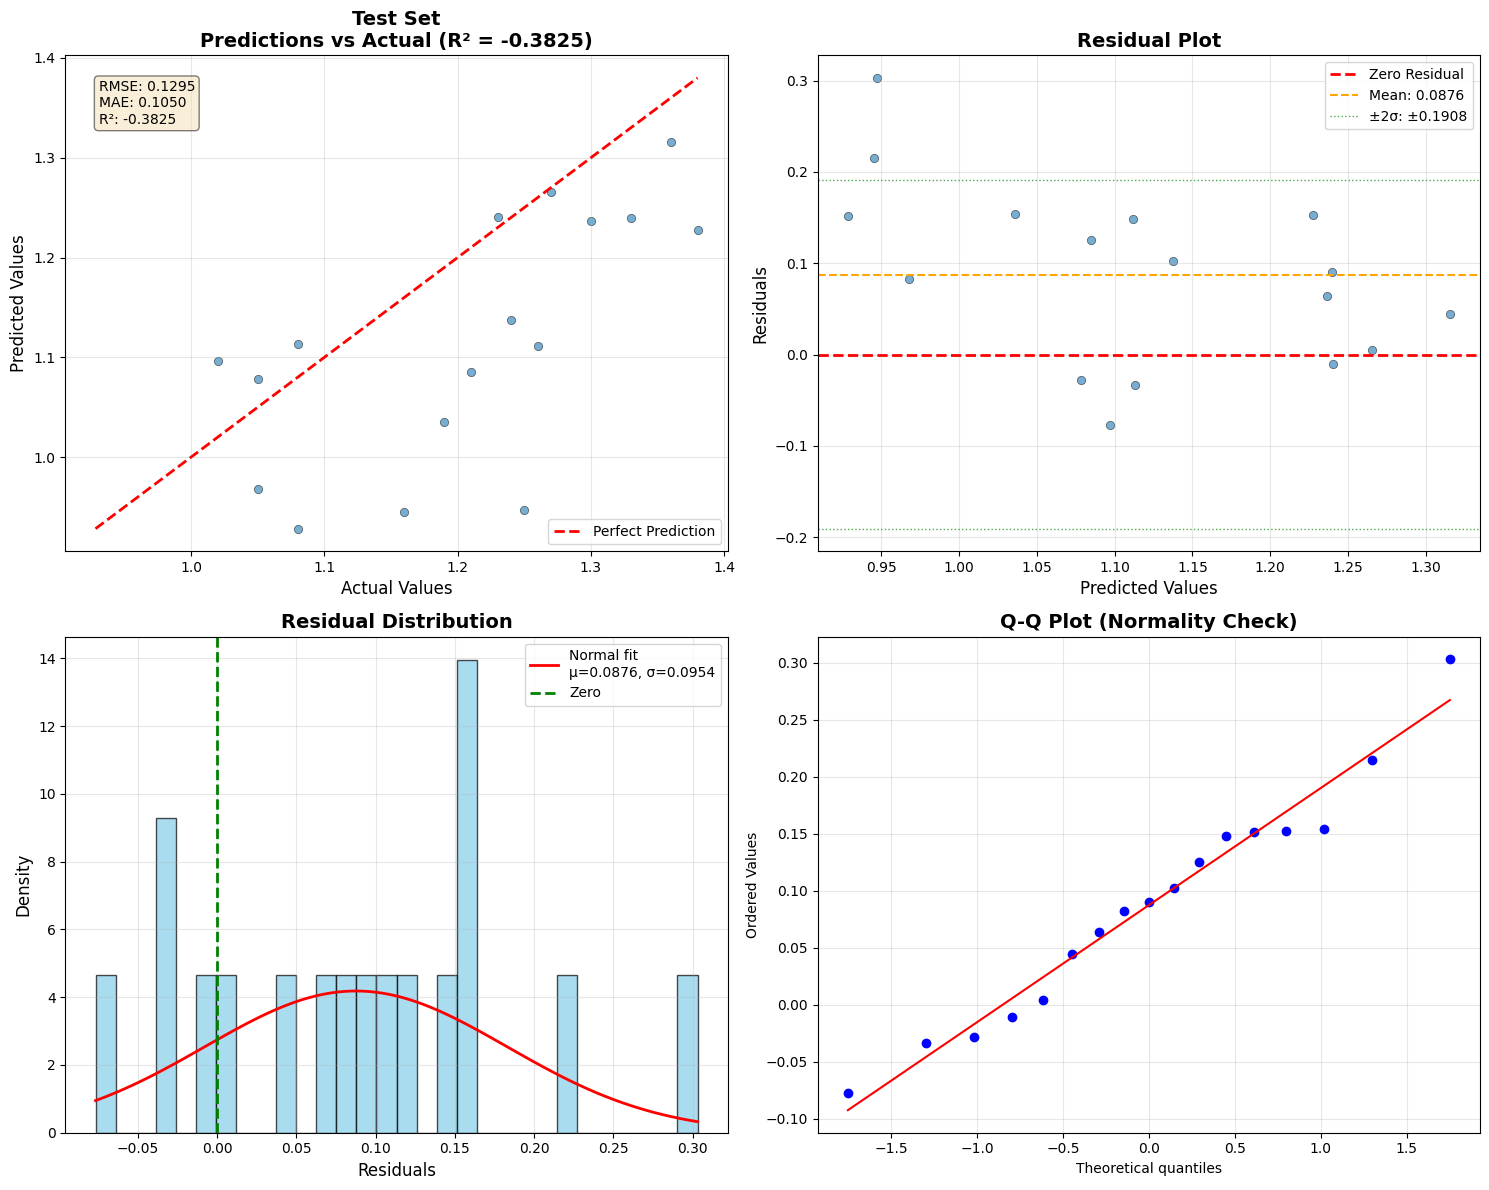


TEST SET - METRICS
R² Score:          -0.382497
RMSE:              0.129491
MAE:               0.105047
MSE:               0.016768

Residual Mean:     0.087557
Residual Std:      0.095402



In [ ]:
##Analyze residuals and get R² + plots
metrics, residuals = analyze_residuals(y_true, y_pred, title="Test Set")

### FineTunning

In [ ]:
dataset_era5 = YearTempDSMask('/content/drive/MyDrive/Copernicus_lab/NASA-TEMP-LAND-OCEAR-1981-2025/era5-1981-2025-temp-clean.npz',
                          return_mask=True,
                         exclude_2025=False)

mu, std = dataset_era5.return_mu_std()

Dataset loaded. Year range: 1981.0 to 2025.0


In [ ]:
#3 config
# Configuration
config = {
    'model_name': 'YearInjection',
    'in_channels': 117,
    'n_classes': 1,
    'dropout': 0.4,
    'learning_rate': 1e-5,
    'batch_size': 8,
    'n_epochs': 85,
    'use_mask': True,
    'freeze_until_layer':'conv2',
    'freeze_early_layers': False,
    'verbose': True
}

## dataloader
### DATASET DATALOADER
# Load dataset
path_openmeteo_dataset = '/content/drive/MyDrive/Copernicus_lab/NASA-TEMP-LAND-OCEAR-1981-2025/openmeteo-1725-temp.npz'
dataset = YearTempDSMask_Finetun(path_openmeteo_dataset,
                            return_mask=True,
                             mu = mu,
                             std= std)

# Split into train/val/test
total_len = len(dataset)
train_size = int(0.87 * total_len)
val_size = int(0.93 * total_len) # 0.80 to 0.95 is 15%

# Chronological slicing using Subset
train_dataset = torch.utils.data.Subset(dataset, range(0, train_size))
val_dataset = torch.utils.data.Subset(dataset, range(train_size, val_size))
test_dataset = torch.utils.data.Subset(dataset, range(val_size, len(dataset)))

## DATALOADER
train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=config['batch_size'], shuffle=False)


# Verification
print(f"Train range: {dataset.get_month_year(0)} to {dataset.get_month_year(train_size-1)}")
print(f"Val range:   {dataset.get_month_year(train_size)} to {dataset.get_month_year(val_size-1)}")
print(f"Test range:  {dataset.get_month_year(val_size)} to {dataset.get_month_year(len(dataset)-1)}")

print(f"Traindataset:{len(train_dataset)}")
print(f"Val:{len(val_dataset)}")
print(f"Test:{len(test_dataset)}")

Dataset loaded from /content/drive/MyDrive/Copernicus_lab/NASA-TEMP-LAND-OCEAR-1981-2025/openmeteo-1725-temp.npz:
  - Samples: 108
  - Capitals: 117
  - Timepoints: 31
  - Shape: (108, 117, 31)
Dataset loaded. Year range: 2017.0 to 2025.0
Train range: 2017-01 to 2024-09
Val range:   2024-10 to 2025-04
Test range:  2025-05 to 2025-12
Traindataset:93
Val:7
Test:8


In [ ]:
train_loader.dataset[0]

(array([[-0.9880992 , -1.0182252 , -0.990755  , ..., -0.6458756 ,
         -0.7250343 ,  0.3021869 ],
        [-0.27386343, -0.22222261, -0.05741321, ...,  0.45775118,
          0.5152899 ,  0.9646626 ],
        [-2.0201547 , -1.0542847 , -1.8277433 , ...,  0.21172336,
          0.17015009,  0.82739216],
        ...,
        [-1.3004149 , -1.1524725 , -0.73066217, ..., -0.888761  ,
         -0.9265864 , -1.2722889 ],
        [-1.5824194 , -1.8390809 , -1.7543255 , ..., -1.7627963 ,
         -1.8945091 , -1.3292519 ],
        [-1.3611611 , -1.5358791 , -1.7647026 , ..., -2.2875605 ,
         -1.7106316 , -0.53778595]], dtype=float32),
 array([1.02], dtype=float32),
 tensor([[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]]),
 tensor([2017.]))

In [ ]:
## create a new directory to save the model weights
checkpoints_dir_fine =Path('fine_tunning_checkpoints')
os.makedirs(name = checkpoints_dir_fine, exist_ok=True)

# Set up the device to train the model to GPU by default if it is avaible, otherwise CPU
device = th.device("cuda" if th.cuda.is_available() else "cpu")
print("Device: ", device)

# Load the pre-trained model
pretrained_model_path = os.path.join(checkpoints_dir / "model_checkpoint.pth")

checkpoint = torch.load(pretrained_model_path, map_location=device)

# Initialize model
model = YearInjection(in_channels=117, n_classes=1, dropout=config['dropout'])
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)

print(f"Loaded pre-trained model from epoch {checkpoint['epoch']}")
print(f"Pre-trained validation loss: {checkpoint['val_loss']:.6f}")

if config['freeze_early_layers'] or config['freeze_until_layer']:
  layers_to_freeze = []

  if config['freeze_until_layer']:
      # Freeze specific layers up to a point
      freeze_map = {
          'conv1': ['conv1'],
          'conv2': ['conv1', 'conv2'],
          'conv3': ['conv1', 'conv2', 'conv3'],
          'conv4': ['conv1', 'conv2', 'conv3', 'conv4'],
      }
      layers_to_freeze = freeze_map.get(config['freeze_until_layer'], [])
  elif config['freeze_early_layers']:
      # Default: freeze first two conv layers
      layers_to_freeze = ['conv1', 'conv2']

  for layer_name in layers_to_freeze:
      layer = getattr(model, layer_name)
      for param in layer.parameters():
          param.requires_grad = False
      if config['verbose']:
          print(f"Froze layer: {layer_name}")

# Count trainable parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
if config['verbose']:
  print(f"Trainable parameters: {trainable_params:,} / {total_params:,} "
        f"({100 * trainable_params / total_params:.1f}%)")

# Initialize optimizer with lower learning rate for fine-tuning
optimizer = torch.optim.Adam(
  filter(lambda p: p.requires_grad, model.parameters()),
  lr=config['learning_rate']
)

## new wandb config
wandb_config = {}
wandb_config.update({
    'fine_tuning': True,
    'pretrained_model': str(pretrained_model_path),
    'learning_rate': config['learning_rate'],
    'epoch_size':config['n_epochs'],
    'freeze_early_layers': config['freeze_early_layers'],
    'freeze_until_layer': config['freeze_until_layer'],
})

wandb_run_name = f"finetune_{generate_run_name(wandb_config)}"

# Use the existing train_model function
results_epoch_df, results_train_df = train_model(
    model=model,
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    n_epochs=config['n_epochs'],
    resultfolder=checkpoints_dir_fine,
    device=device,
    use_mask=True,
    use_wandb=True,
    wandb_project='temperature-prediction-lstm',
    wandb_config=wandb_config,
    wandb_run_name=wandb_run_name,
    verbose=True
)

Device:  cuda
Loaded pre-trained model from epoch 40
Pre-trained validation loss: 0.008050
Froze layer: conv1
Froze layer: conv2
Trainable parameters: 501,057 / 1,308,481 (38.3%)


wandb run: finetune_LSTM_lr1e-05_20260302_221930
wandb url: https://wandb.ai/emanuelgoulartf-paris-lodron-universit-t-salzburg/temperature-prediction-lstm/runs/artxiji2
Epoch 0 (initial): train loss=0.05283, train MSE=0.052601, val loss=0.04112, val MSE=0.04112
Epoch 1: train loss=0.146797, train MSE=0.146797, val loss=0.082937, val MSE=0.082937
Epoch 2: train loss=0.133455, train MSE=0.133455, val loss=0.086114, val MSE=0.086114
Epoch 3: train loss=0.121744, train MSE=0.121744, val loss=0.101318, val MSE=0.101318
Epoch 4: train loss=0.113282, train MSE=0.113282, val loss=0.098174, val MSE=0.098174
Epoch 5: train loss=0.120363, train MSE=0.120363, val loss=0.095932, val MSE=0.095932
Epoch 6: train loss=0.102115, train MSE=0.102115, val loss=0.090123, val MSE=0.090123
Epoch 7: train loss=0.099215, train MSE=0.099215, val loss=0.085319, val MSE=0.085319
Epoch 8: train loss=0.100672, train MSE=0.100672, val loss=0.077791, val MSE=0.077791
Epoch 9: train loss=0.098831, train MSE=0.098831, 

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇████
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,▃█▇█▆▅▅▅▄▄▄▃▄▃▃▂▂▃▂▃▂▃▂▂▂▃▂▂▂▁▂▂▂▃▃▁▂▂▂▂
train_mse,▂█▇▇▅▄▃▄▃▃▃▂▃▂▂▂▂▃▂▁▂▂▂▂▂▂▂▂▂▂▂▂▂▁▂▁▂▂▂▁
val_loss,▄▇▇█▇▅▅▄▄▄▂▂▂▂▂▁▁▂▂▂▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_mse,▄██▆▆▄▄▄▃▂▂▁▂▂▂▁▁▁▂▂▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁
best_epoch,60
best_val_loss,0.00834
best_val_mse,0.00834
epoch,85
learning_rate,1e-05


In [ ]:
## TESTING
# Reload the mpodel's arameters of the best performing model (lowest validation loss)
model.load_state_dict(th.load(checkpoints_dir_fine / "model_checkpoint.pth")["model_state_dict"])
model.to(device)
test_loss, test_mse, (y_true, y_pred) = evaluate_model(model,
                                                       test_dataloader,
                                                       criterion, device,
                                                       use_mask=True)


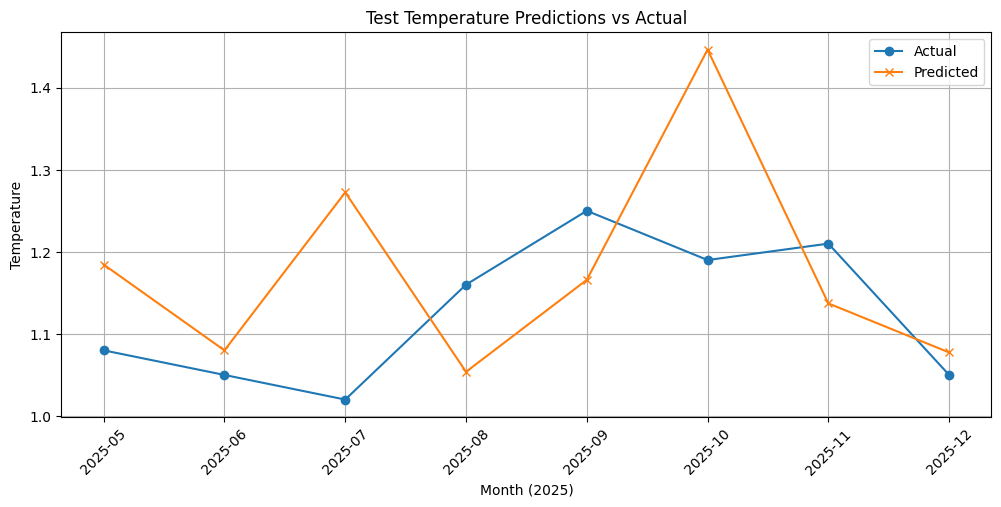

In [ ]:
list_test_dates = []
for dd in test_dataloader.dataset.indices:
  list_test_dates.append(dataset.month_years[dd])

list_test_dates = [str(s) for s in list_test_dates]

plot_predictions(y_true, y_pred,list_test_dates, title="Test Set")

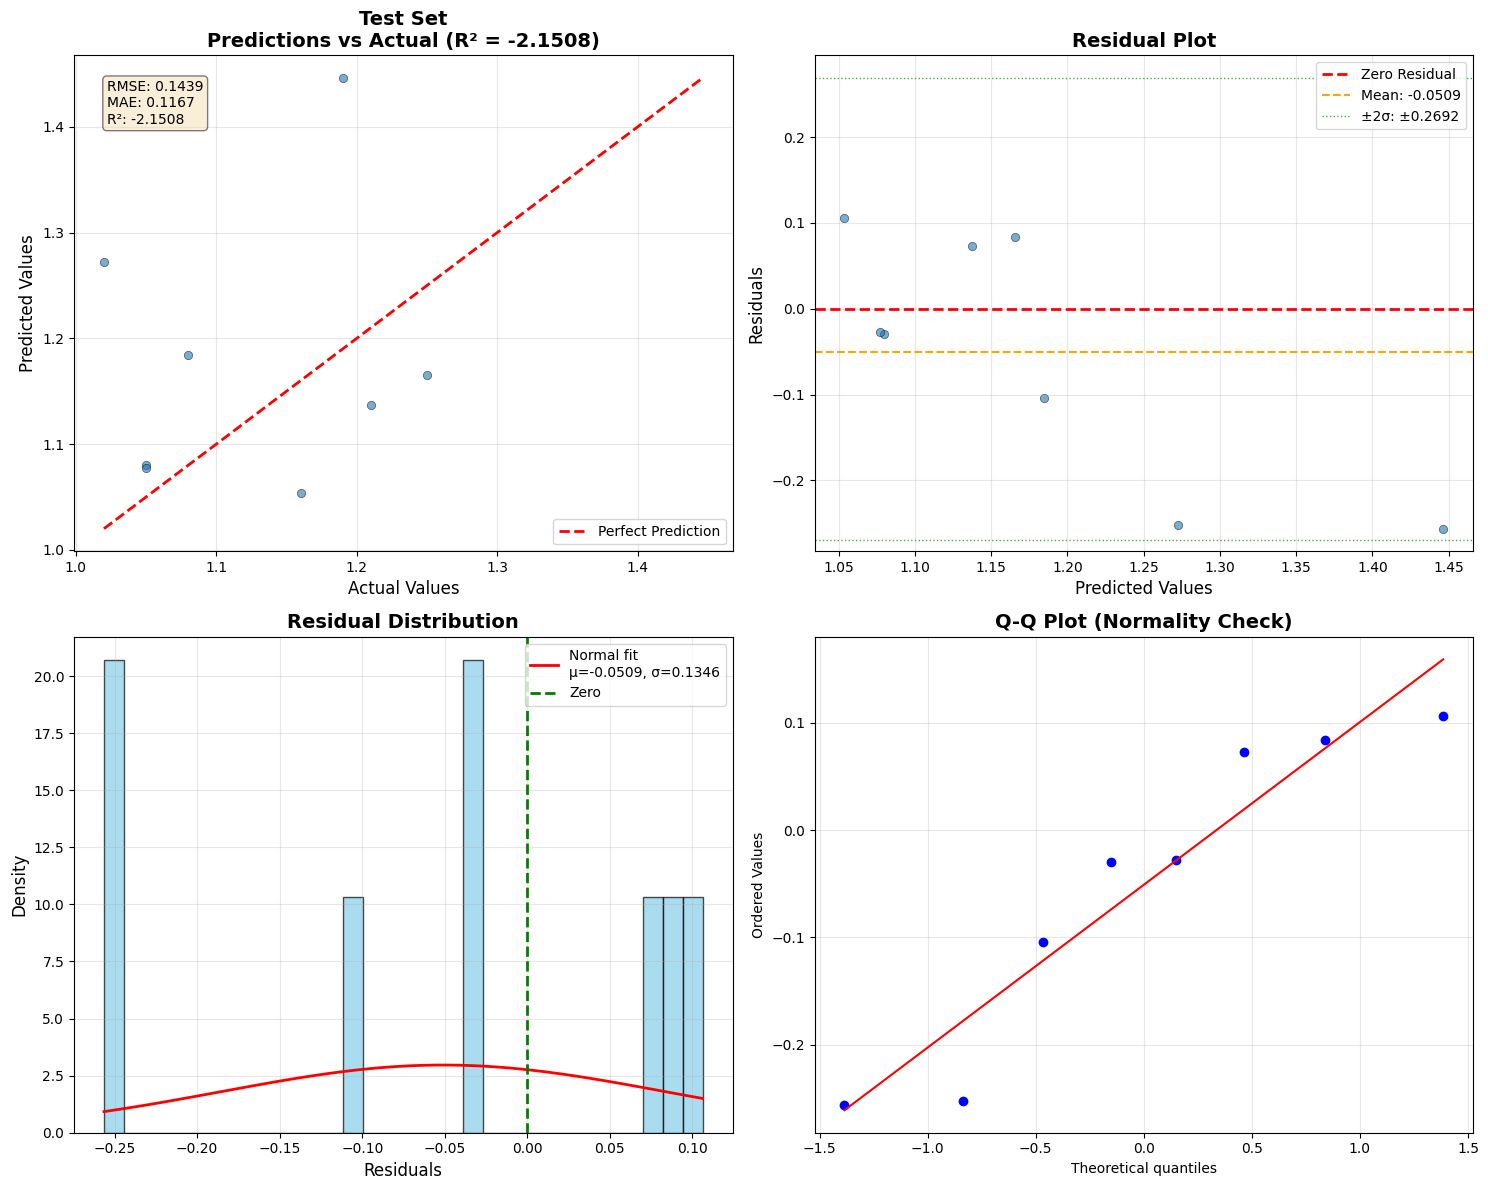


TEST SET - METRICS
R² Score:          -2.150849
RMSE:              0.143916
MAE:               0.116733
MSE:               0.020712

Residual Mean:     -0.050941
Residual Std:      0.134599



In [ ]:
##Analyze residuals and get R² + plots
metrics, residuals = analyze_residuals(y_true, y_pred, title="Test Set")

In [ ]:
## load the tensor of temperatures for jan/2026
jan_2026_path = '/content/drive/MyDrive/Copernicus_lab/NASA-TEMP-LAND-OCEAR-1981-2025/openmeteo-jan26.npz'
tt = np.load(jan_2026_path, allow_pickle=True)

tm = tt['temp_matrices']
tm_mask = tt['masks']
year = torch.tensor([[2026.0]], device=device)
## normalize
tt = torch.tensor(tm, dtype=torch.float32)
tts = (tt - mu) / (std + 1e-8)  # Add epsilon to avoid division by zero

### pass to device
tts = tts.to(device)
year = year.to(device)
tm_mask = torch.tensor(tm_mask).to(device)

##
model.eval()
result = model(tts, year, mask=tm_mask)
print(result)

tensor([[1.0955]], device='cuda:0', grad_fn=<AddmmBackward0>)


In [ ]:
tt.shape

torch.Size([1, 117, 31])

In [ ]:
tt['masks']

/tmp/ipykernel_1609/3152290878.py:1: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  tt['masks']


IndexError: too many indices for tensor of dimension 3

In [ ]:
ttt = next(iter(tt))

In [ ]:
ttt.shape

torch.Size([117, 31])

In [ ]:
ttt

tensor([[ 19.8333,  19.5083,  22.0104,  ...,  20.0125,  19.6354,  19.2333],
        [ 29.9083,  29.0938,  29.9563,  ...,  29.1833,  29.4229,  29.6729],
        [ 13.7125,  13.7354,  13.0188,  ...,  16.2667,  15.8479,  15.9583],
        ...,
        [-27.3604, -33.9167, -40.1792,  ..., -30.2396, -33.1479, -34.9021],
        [ -3.7160,  -9.7056,  -8.8077,  ...,  -2.4827,   0.2423,   3.0173],
        [  4.5146,   1.5875,   0.3271,  ...,   4.0312,   3.4667,   2.8917]])

In [ ]:
## load the tensor of temperatures for jan/2026
jan_2026_path = '/content/drive/MyDrive/Copernicus_lab/NASA-TEMP-LAND-OCEAR-1981-2025/openmeteo-janfev26.npz'
tt = np.load(jan_2026_path, allow_pickle=True)

tm = tt['temp_matrices']
tm_mask = tt['masks']
year = torch.tensor([[2026.0],[2026.0]], device=device)
## normalize
tt = torch.tensor(tm, dtype=torch.float32)
tts = (tt - mu) / (std + 1e-8)  # Add epsilon to avoid division by zero

### pass to device
tts = tts.to(device)
year = year.to(device)
tm_mask = torch.tensor(tm_mask).to(device)

##
model.eval()
result = model(tts, year, mask=tm_mask)
print(result)

tensor([[1.1011],
        [1.1581]], device='cuda:0', grad_fn=<AddmmBackward0>)


In [ ]:
tm.shape

(2, 117, 31)

In [ ]:
tm_mask.shape

torch.Size([2, 117, 31])

In [ ]:
year.shape

torch.Size([1, 2])

In [ ]:
tts.shape

torch.Size([2, 117, 31])

# Detrending

In [ ]:
from sklearn.linear_model import LinearRegression

def calculate_trend_params(years, labels):
    """
    Fits a line: Temp = slope * Year + intercept
    """
    model = LinearRegression()
    model.fit(years.reshape(-1, 1), labels.reshape(-1, 1))
    return model.coef_[0][0], model.intercept_[0]

# Example usage with your training indices:
train_years = dataset.years[:108]
train_labels = dataset.labels[:108]
slope, intercept = calculate_trend_params(train_years, train_labels)

print(f"Calculated Drift: {slope:.5f} °C per year")

Calculated Drift: 0.04389 °C per year


In [ ]:
len(dataset.years)

108

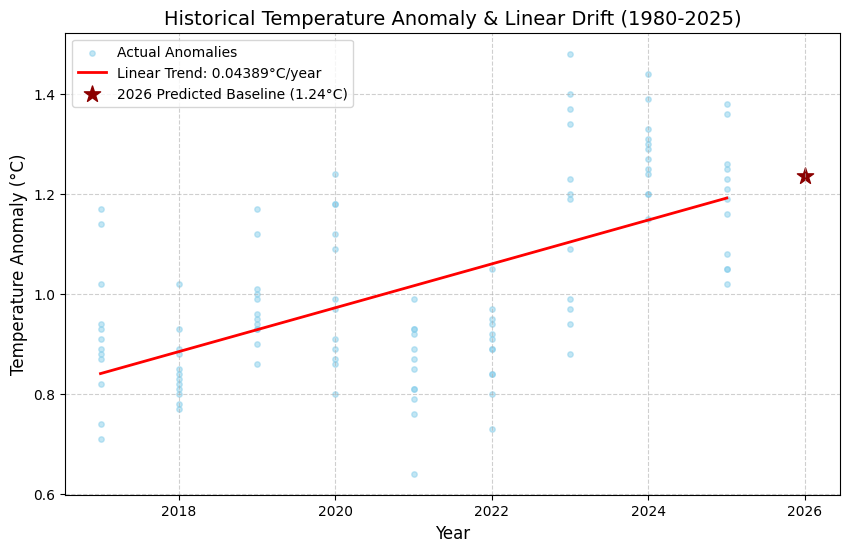

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate the trend line values
# Actual = slope * Year + intercept
trend_line = slope * train_years + intercept

# 2. Create the plot
plt.figure(figsize=(10, 6))

# Plot the actual data points
plt.scatter(train_years, train_labels, color='skyblue', alpha=0.5, label='Actual Anomalies', s=15)

# Plot the linear regression line (The Drift)
plt.plot(train_years, trend_line, color='red', linewidth=2,
         label=f'Linear Trend: {slope:.5f}°C/year')

# 3. Highlight the 2026 Prediction (Extrapolation)
year_2026 = 2026.0
baseline_2026 = (slope * year_2026) + intercept
plt.scatter([year_2026], [baseline_2026], color='darkred', marker='*', s=150,
            label=f'2026 Predicted Baseline ({baseline_2026:.2f}°C)')

# Formatting
plt.title('Historical Temperature Anomaly & Linear Drift (1980-2025)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Temperature Anomaly (°C)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()